In [34]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from torch.nn.functional import interpolate

from datasets import load_dataset
from inpaintingStart import *
import argparse

from PIL import Image
import gradio as gr
from imagenet_en_cn import IMAGENET_1K_CLASSES
from omegaconf import OmegaConf

import torch
from transformers import T5EncoderModel, AutoTokenizer

from pixelflow.scheduling_pixelflow import PixelFlowScheduler
from pixelflow.pipeline_pixelflow import PixelFlowPipeline
from pixelflow.utils import config as config_utils
from pixelflow.utils.misc import seed_everything

from sampler2 import PixelFlowPipeline3
import time
import matplotlib.pyplot as plt
import imageio
import math
import copy
from pathlib import Path
from einops import rearrange
# ds = load_dataset("ILSVRC/imagenet-1k")

In [35]:
import os
os.listdir("/home/../mnt/data3/ruy45")

['dataset', 'dataset0']

In [36]:
data_dir = '/home/../mnt/data3/ruy45/dataset/imageNet256/ILSVRC/Data/CLS-LOC/train/'

def center_crop_arr(pil_image, image_size):
    while min(*pil_image.size) >= 2 * image_size:
        pil_image = pil_image.resize(
            tuple(x // 2 for x in pil_image.size), resample=Image.BOX
        )

    scale = image_size / min(*pil_image.size)
    pil_image = pil_image.resize(
        tuple(round(x * scale) for x in pil_image.size), resample=Image.BICUBIC
    )

    arr = np.array(pil_image)
    crop_y = (arr.shape[0] - image_size) // 2
    crop_x = (arr.shape[1] - image_size) // 2
    return Image.fromarray(arr[crop_y: crop_y + image_size, crop_x: crop_x + image_size])

transform = transforms.Compose([
    transforms.Lambda(lambda pil_image: center_crop_arr(pil_image, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)])
dataset = ImageFolder(data_dir, transform=transform)

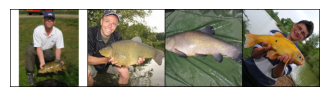

In [37]:
loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=False, num_workers=4)
imgs, labels = next(iter(loader))      # imgs: [B,3,256,256] in [-1,1]
imgs_vis = (imgs * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(imgs_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [ ]:
seed_everything(20000120)
num_stages = 4 # config.scheduler.num_stages
resolution = 256
NUM_EXAMPLES = 4
sigma_n = 0.05
class_label = 10
shift = 1.0
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
output_dir = './pretrained_models/c2img'
box_operator = get_operator("inpainting", mask_type='box', mask_len_range=(80, 160), mask_prob_range=None, resolution=resolution, device=device, sigma=sigma_n)
random_operator = get_operator("inpainting", mask_type='random', mask_prob_range=(0.15, 0.2), resolution=resolution, device=device, sigma=sigma_n)
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
config = OmegaConf.load(f"{output_dir}/config.yaml")
model = config_utils.instantiate_from_config(config.model).to(device)
print(f"Num of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
ckpt = torch.load(f"{output_dir}/model.pt", map_location="cpu", weights_only=False)
model.load_state_dict(ckpt, strict=True)
model.eval()
text_encoder = None
tokenizer = None
scheduler = PixelFlowScheduler(config.scheduler.num_train_timesteps, num_stages=config.scheduler.num_stages, gamma=-1/3)
scheduler_copy = copy.deepcopy(scheduler)
sampler_pipeline = PixelFlowPipeline3(scheduler_copy,model,text_encoder=text_encoder,tokenizer=tokenizer, max_token_length=512,)


Starting Initialization...
Num of parameters: 676611120


In [39]:
if class_label:
    # target_class_name = 'n01440764'   # If class label available
    # class_label = dataset.class_to_idx[target_class_name]
    class_indices = [i for i, (_, y) in enumerate(dataset.samples) if y == class_label]
    perm = torch.randperm(len(class_indices))[:NUM_EXAMPLES]
    selected_indices = [class_indices[i] for i in perm]
    gt = torch.stack([dataset[i][0] for i in selected_indices], dim=0)
    labels = [dataset[i][1] for i in selected_indices]
else:
    idx = torch.randperm(len(dataset))[:NUM_EXAMPLES]
    gt = torch.stack([dataset[i][0] for i in idx], dim=0) 
    labels = [dataset[i][1] for i in idx]

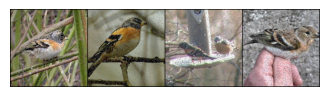

In [40]:
sigma_n =0.05
A_opr = random_operator
y = A_opr.measure(gt)
y_vis = (y * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

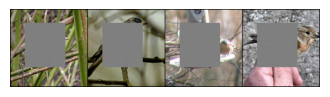

In [41]:
sigma_n =0.05
A_opr = box_operator
y = A_opr.measure(gt)
y_vis = (y * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=4)     # [3,H,W]
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [42]:
def sample_block_noise(scheduler, bs, ch, height, width, eps=1e-6):
    gamma = scheduler.gamma
    dist = torch.distributions.multivariate_normal.MultivariateNormal(torch.zeros(4), torch.eye(4) * (1 - gamma) + torch.ones(4, 4) * gamma + eps * torch.eye(4))
    block_number = bs * ch * (height // 2) * (width // 2)
    noise = torch.stack([dist.sample() for _ in range(block_number)]) # [block number, 4]
    noise = rearrange(noise, '(b c h w) (p q) -> b c (h p) (w q)',b=bs,c=ch,h=height//2,w=width//2,p=2,q=2)
    return noise
def T_to_t_linear(Timesteps, t, T):
    '''
    provide global T to get local t at the stage.
    '''
    T_end = Timesteps[-1]
    T_start = Timesteps[0]
    t_end = t[-2]
    t_start = t[0]
    k = (T_end - T_start) / (t_end - t_start)
    b = T_start - t_start * k
    return (T-b)/k
def get_xt_from_x1(scheduler, Timesteps, x1, stage_idx, T, noise = None):
    start_t, end_t = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
    resolution = x1.shape[-1]
    pixel_values_end = x1
    pixel_values_start = x1
    if stage_idx < num_stages - 1:
        # pixel_values_end
        for downsample_idx in range(1, num_stages - stage_idx):
            pixel_values_end = F.interpolate(pixel_values_end, (resolution // (2 ** downsample_idx), resolution // (2 ** downsample_idx)), mode="bilinear")

        # pixel_values_start
    
    for downsample_idx in range(1, num_stages - stage_idx + 1):
        pixel_values_start = F.interpolate(pixel_values_start, (resolution // (2 ** downsample_idx), resolution // (2 ** downsample_idx)), mode="bilinear")
    # upsample pixel_values_start
    end_height, end_width = pixel_values_end.shape[-1], pixel_values_end.shape[-2]
    pixel_values_start = F.interpolate(pixel_values_start, (end_height, end_width), mode="nearest")
    if noise == None:
        noise = torch.randn_like(pixel_values_end)
    pixel_values_end = end_t * pixel_values_end + (1.0 - end_t) * noise
    # print(pixel_values_end.shape, pixel_values_start.shape, noise.shape)
    pixel_values_start = start_t * pixel_values_start + (1.0 - start_t) * noise

    # Ts = scheduler.Timesteps_per_stage[stage_idx].to(torch.float64)
    # k = int(torch.argmin(torch.abs(Ts - T)).item())              # nearest index
    # t_select = torch.tensor(scheduler.t_window_per_stage[stage_idx][k].item(), dtype = torch.float32, device = device) 
    t_select = T_to_t_linear(Timesteps, scheduler.t, T).to(device)
    xt = t_select.float() * pixel_values_end.to(device) + (1.0 - t_select.float()) * pixel_values_start.to(device)
    # print(start_t, end_t, T, t_select)
    return xt
# def get_xt_from_x1_sameStage(scheduler, Timesteps, D_x1, stage_idx, step_idx, DU_x0 = None, noise = None):
#     start_t, end_t = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
#     if noise == None:
#         noise = torch.randn_like(D_x1)
#     pixel_values_end = end_t * D_x1 + (1.0 - end_t) * noise
#     if DU_x0 == None:
#         pixel_values_start = start_t * DownUp_operation(D_x1) + (1.0 - start_t) * noise
#     else:
#         pixel_values_start = DU_x0
#     xt = scheduler.t[step_idx].float() * pixel_values_end.to(device) + (1.0 - scheduler.t[step_idx].float()) * pixel_values_start.to(device)
#     return xt

def get_xt_from_x1_sameStage(scheduler, Timesteps, D_x1, stage_idx, step_idx, DU_x0 = None, noise = None):
    start_t, end_t = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
    if DU_x0 == None:
        if noise == None:
            noise = torch.randn_like(D_x1)
        pixel_values_end = end_t * D_x1 + (1.0 - end_t) * noise
        pixel_values_start = start_t * DownUp_operation(D_x1) + (1.0 - start_t) * noise
    else:
        pixel_values_start = DU_x0.clone()
        pixel_values_end =  end_t * D_x1 + (1.0 - end_t)/(1.0-start_t) * (pixel_values_start - start_t * DownUp_operation(D_x1))

    xt = scheduler.t[step_idx].float() * pixel_values_end.to(device) + (1.0 - scheduler.t[step_idx].float()) * pixel_values_start.to(device)
    return xt

In [43]:
scheduler_copy.set_timesteps(10, 3, device=device, shift=shift)
Timesteps3 = scheduler_copy.Timesteps

In [44]:
Timesteps3, scheduler_copy.start_t, scheduler_copy.end_t, 

(tensor([719.0000, 750.1111, 781.2222, 812.3333, 843.4444, 874.5556, 905.6667,
         936.7778, 967.8889, 999.0000], device='cuda:1', dtype=torch.float64),
 {0: 0.0,
  1: 0.14285714285714285,
  2: 0.3333333333333333,
  3: 0.6000000000000001},
 {0: 0.25, 1: 0.5, 2: 0.75, 3: 1.0})

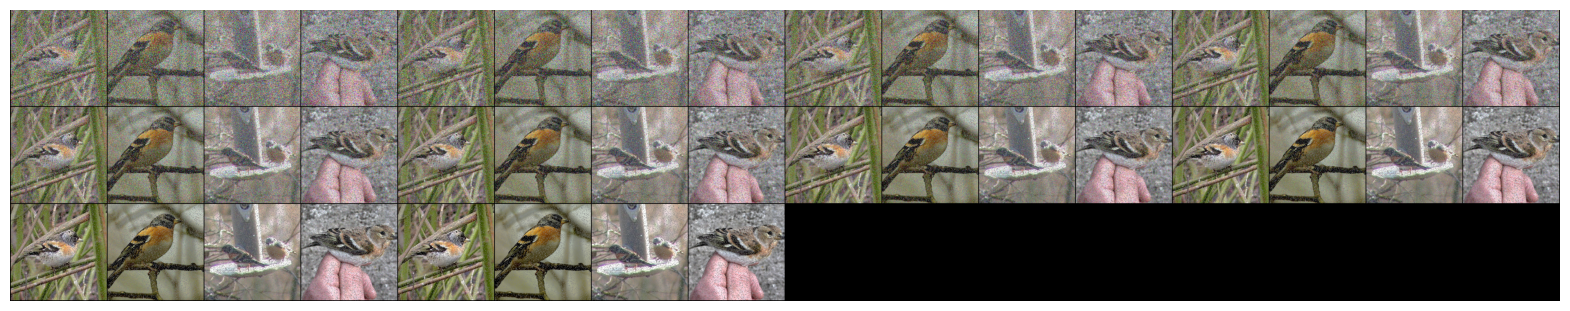

In [45]:
xts = []
ys = []
for T in Timesteps3:
    xt = get_xt_from_x1(scheduler_copy, Timesteps3, gt, 3, T)
    xts.append(xt)
    yt = get_xt_from_x1(scheduler_copy, Timesteps3, random_operator(gt), 3, T)
    ys.append(yt)
ys = torch.concat(ys, dim = 0)
xts = torch.concat(xts, dim = 0)

y_vis = (ys.cpu().cpu() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=16)     # [3,H,W]
plt.figure(figsize=(20, 32))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()


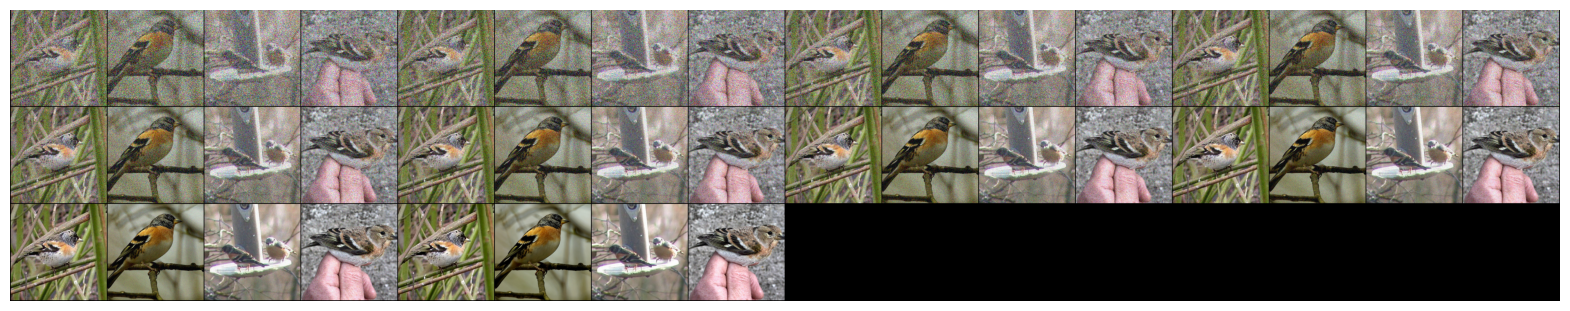

In [46]:
y_vis = (xts.cpu().cpu() * 0.5 + 0.5).clamp(0, 1)
grid = make_grid(y_vis, nrow=16)     # [3,H,W]
plt.figure(figsize=(20, 32))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()


In [47]:
def Up_k(x, y):
    target_hw = y.shape[-2:]
    target_h, target_w = target_hw
    if x.shape[-2:] == target_hw:
        return x
    else:
        h, w = x.shape[-2:]

        out = x
        while h < target_h or w < target_w:
            next_h = min(h * 2, target_h)
            next_w = min(w * 2, target_w)

            out = F.interpolate(
                out,
                size=(next_h, next_w),
                mode="bilinear",
            )
            h, w = next_h, next_w

        if (h, w) != (target_h, target_w):
            out = F.interpolate(
                out,
                size=(target_h, target_w),
                mode="bilinear",
            )
        return out

def DownUp_operation(z, scale_factor=2):
    B, C, H, W = z.shape
    h_small = H // scale_factor
    w_small = W // scale_factor

    z_down = F.interpolate(
        z, size=(h_small, w_small),
        mode="bilinear",
    )
    z_up = F.interpolate(
        z_down, size=(H, W),
        mode='nearest',
    )
    return z_up

In [15]:
def objective_split_prior(x0hat, operator, stage_t_end, stage_t_start, stage_x_end, stage_x_start, y, sigma_n, o_M):
    # Match data end
    stage_x_end = stage_x_end.requires_grad_(False)
    stage_x_start = stage_x_start.requires_grad_(False)
    # x_up_proj = (1-o_M)*operator(Up_k(x0hat, y)) + o_M*y
    x_up_proj = operator(Up_k(x0hat, y))
    l3 = (1/(2*sigma_n**2)*(x_up_proj- y)**2).mean()

    # Optional smooth regularization on x0hat.
    # if self.split_prior_smooth_weight > 0:
    #     dx = x0hat[:, :, 1:, :] - x0hat[:, :, :-1, :]
    #     dy = x0hat[:, :, :, 1:] - x0hat[:, :, :, :-1]
    #     l_smooth = self.split_prior_smooth_weight * (dx.pow(2).mean() + dy.pow(2).mean())
    # else:
    #     l_smooth = x0hat.new_tensor(0.0)
    # return l3
    var_eps = 1e-5 # in case of 0 as a denominator
    denom_end = max(float((1 - stage_t_end) ** 2), var_eps)
    denom_start = max(float((1 - stage_t_start) ** 2), var_eps)
    l1 = (1 / (2 * denom_end) * (stage_x_end - stage_t_end * x0hat) ** 2).mean()
    l2 = (1 / (2 * denom_start) * (stage_x_start - stage_t_start * DownUp_operation(x0hat)) ** 2).mean()
    return l1 + l2 + l3, l1, l2, l3

    # return l1 + l2 + l3 + l_smooth

In [ ]:
# def objective_split_prior(x0hat, operator, stage_t_end, stage_t_start, stage_x_end, stage_x_start, y, sigma_n, o_M):
#     # Match data end
#     stage_x_end = stage_x_end.requires_grad_(False)
#     stage_x_start = stage_x_start.requires_grad_(False)
#     # x_up_proj = (1-o_M)*operator(Up_k(x0hat, y)) + o_M*y
#     x_up_proj = operator(Up_k(x0hat, y))
#     l3 = (1/(2*sigma_n**2)*(x_up_proj- y)**2).mean()

#     # Optional smooth regularization on x0hat.
#     # if self.split_prior_smooth_weight > 0:
#     #     dx = x0hat[:, :, 1:, :] - x0hat[:, :, :-1, :]
#     #     dy = x0hat[:, :, :, 1:] - x0hat[:, :, :, :-1]
#     #     l_smooth = self.split_prior_smooth_weight * (dx.pow(2).mean() + dy.pow(2).mean())
#     # else:
#     #     l_smooth = x0hat.new_tensor(0.0)
#     # return l3
#     var_eps = 1e-5 # in case of 0 as a denominator
#     denom_end = max(float((1 - stage_t_end) ** 2), var_eps)
#     denom_start = max(float((1 - stage_t_start) ** 2), var_eps)
#     l1 = (1 / (2 * denom_end) * (stage_x_end - stage_t_end * x0hat) ** 2).mean()
#     l2 = (1 / (2 * denom_start) * (stage_x_start - stage_t_start * DownUp_operation(x0hat)) ** 2).mean()
#     return l1 + l2 + l3, l1, l2, l3

#     # return l1 + l2 + l3 + l_smooth

In [48]:
@torch.no_grad()
def langevin_update_split_prior(
    x: torch.Tensor,
    y: torch.Tensor,
    operator,
    stage_t_end, 
    stage_t_start, 
    stage_x_end: torch.Tensor,
    stage_x_start: torch.Tensor,
    sigma_n: float,                   
    step_size: float, 
    o_M,
    device,
):
    x = x.to(device)
    y = y.to(device)
    """
    One step overdamped Langevin for p(x) ∝ exp(-L(x)).
    L(x) = 1/(2σ_n^2)||Hx-y||^2 + 1/(2ν_t^2)||x-x1hat||^2
    """
    with torch.enable_grad():
        x = x.detach().requires_grad_(True)
        # loss = objective_split_prior(x, operator, stage_t_end, stage_t_start, stage_x_end, stage_x_start, y, sigma_n, o_M)
        loss, l1,l2,l3 = objective_split_prior(x, operator, stage_t_end, stage_t_start, stage_x_end, stage_x_start, y, sigma_n, o_M)
        grad = torch.autograd.grad(loss, x)[0]
    grad_norm = grad.norm().item()
    delta_norm = (step_size * grad).norm().item()
    # grad = torch.nan_to_num(grad, nan=0.0, posinf=0.0, neginf=0.0)
    # if self.langevin_grad_clip is not None:
    #     grad_norm = grad.norm().clamp_min(1e-12)
    #     clip_val = grad.new_tensor(self.langevin_grad_clip)
    #     grad = grad * torch.clamp(clip_val / grad_norm, max=1.0)
    x_new = x - step_size*grad + math.sqrt(2.0 * step_size)*torch.randn_like(x)
    # x_new = x - step_size*grad 
    # x_new = torch.nan_to_num(x_new, nan=0.0, posinf=1e6, neginf=-1e6)
    # if langevin_x_clamp is not None:
    #     x_new = torch.clamp(x_new, -langevin_x_clamp, langevin_x_clamp)
    return x_new, {
        "loss": f"{float(loss.detach().cpu()):.5f}",
        "l1": f"{float(l1.detach().cpu()):.5f}",
        "l2": f"{float(l2.detach().cpu()):.5f}",
        "l3": f"{float(l3.detach().cpu()):.5f}",
        "grad_norm": f"{grad_norm:.5f}",
        "delta_norm": f"{delta_norm:.5f}",
        "z_mean": f"{float(x_new.mean().detach().cpu()):.5f}",
        "z_std": f"{float(x_new.std().detach().cpu()):.5f}",
    }
def langevin_sample_split_prior(
    x_init, y, operator, stage_t_end,stage_t_start, stage_x_end, stage_x_start, num_Langevin,
    sigma_n, 
    step_size=1e-4,
    device = "cpu",
    proj = False,
    return_traj = False
):
    if proj:
        if hasattr(operator, "get_mask"):
            o_M = operator.get_mask(x=y).to(device)
        else:
            o_M = operator.mask.to(device)
    else:
        o_M = torch.zeros_like(y, device=device)
    x = x_init.clone().detach()
    for _ in range(num_Langevin):
        x,record = langevin_update_split_prior(x,y,operator, stage_t_end, stage_t_start, 
                                                stage_x_end, stage_x_start, sigma_n,  step_size, o_M, device)
        if return_traj:
            if _ % 10 == 0:
                print(record)
        # if torch.isnan(x).any():
        #     break
    return x.detach()

In [49]:
def plot(latents, nrow, save_name =None):
    if isinstance(latents, list):
        latents = torch.concat(latents, dim = 0)
    y_vis = (latents.cpu().cpu() * 0.5 + 0.5).clamp(0, 1)
    grid = make_grid(y_vis, nrow=nrow)     # [3,H,W]
    plt.figure(figsize=(5*nrow/4, 8*nrow/4))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    if save_name != None:
        plt.savefig(f"{save_name}.png", bbox_inches="tight", pad_inches=0)
    plt.show()

In [50]:
def pred_x1_x0_with_vt(xt, vt, T, start_t, end_t):
    x1_normal = xt + (1-T/1000)/(end_t - start_t)*vt
    x0_normal = xt - T/1000*(end_t - start_t)*vt
    return x1_normal, x0_normal

In [51]:
def get_x1_and_noise_with_stage_start_and_end(xe, xs, scheduler, stage_idx):
    '''
    xs: x stage start
    xe: x stage end
    stage_idx: 0-3, 3: original resolution
    return: x1: data, x0: noise
    Note: x1 and x0 are predicted version, we use x1 only as an initial, x0 will not be used. However, since xe and xs are predicted data, 
        e-s will enlarge the error.
    '''
    def get_global_stage_window(stage_idx):
        start_t = scheduler.start_t[stage_idx]
        end_t = scheduler.end_t[stage_idx]
        d = [scheduler.end_t[i] - scheduler.start_t[i] for i in range(scheduler.num_stages)]
        D = sum(d)

        global_start = sum(d[:stage_idx]) / D
        global_end   = sum(d[:stage_idx + 1]) / D
        return global_start, global_end
    s, e = get_global_stage_window(stage_idx)
    x1 = ((1 - s)*xe - (1 - e)*xs)/ (e - s)
    x0 = (e*xs -s*xe)/(e-s)
    return x1, x0, e, s
    # Tested, x1 looks good but x0 looks a little bit strange but it's not used.
def get_x1_and_noise_with_stage_start_and_end2(xe, xs, scheduler, stage_idx):
    '''
    follow the training t
    '''
    s, e = scheduler.start_t[stage_idx], scheduler.end_t[stage_idx]
    x1 = ((1 - s)*xe - (1 - e)*xs)/ (e - s)
    x0 = (e*xs -s*xe)/(e-s)
    return x1, x0, e, s
    # Tested, x1 looks good but x0 looks a little bit strange but it's not used.



def get_lr(ratio):
    p = langevin_step_p = 1 # set it fixed for now
    lr_min_ratio = langevin_step_min_ratio = 1e-2 # set it fixed for now
    multiplier = (1 ** (1 / p) + ratio * (lr_min_ratio ** (1 / p) - 1 ** (1 / p))) ** p
    return multiplier * 1e-4 # set the lr base

# Baseline 1: inject noise to get $x_t^k$, show prediction of $\hat x_{t+1}^k$, $\hat x_s^k$, $\hat x_e^k$, $\hat x_0^k$ and $\hat x_1^k$

In [21]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
inference_each_step = 10
guidance_scale = 0
resolution = 256
A_x1 =  random_operator(gt)
xts_from_x1 = []
x1_vpred_traj = []
x0_vpred_traj = []
xs_vpred_traj = []
xe_vpred_traj = []
x1_exppred_traj = []
x0_exppred_traj = []
xs_exppred_traj = []
xe_exppred_traj = []
xtnext_from_vpred_noise = []
xtnext_from_vpred_x0 = []
xtnext_from_vpred_UDx1 = []
xtnext_from_exppred_noise = []
xtnext_from_exppred_x0 = []
xtnext_from_exppred_UDx1 = []




prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

do_classifier_free_guidance = True if guidance_scale > 0 else 0


with torch.no_grad():
    for stage_idx in range(num_stages):
        scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps_k = scheduler_copy.Timesteps
        start_t = scheduler_copy.start_t[stage_idx]
        end_t = scheduler_copy.end_t[stage_idx]

        latents_v = get_xt_from_x1(scheduler_copy, Timesteps_k, A_x1, stage_idx, Timesteps_k[0])

        size_tensor = torch.tensor([latents_v.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
        pos_embed = get_2d_rotary_pos_embed(
            embed_dim=model.attention_head_dim,
            crops_coords=(
                (0, 0),
                (latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            ),
            grid_size=(latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            device=device,
            output_type="pt",)
        rope_pos = torch.stack(pos_embed, -1)

        for step_idx, T in enumerate(Timesteps_k):
            latents_v = get_xt_from_x1(scheduler_copy, Timesteps_k, A_x1, stage_idx, T)
            latents_stage = latents_v.clone()
            xts_from_x1.append(latents_v.clone())


            latent_model_input_v = torch.cat([latents_v] * 2) if do_classifier_free_guidance else latents_v
            latent_model_input_stage = torch.cat([latents_stage] * 2) if do_classifier_free_guidance else latents_stage

            timestep_v = T.expand(latent_model_input_v.shape[0]).to(latent_model_input_v.dtype)
            timestep_stage = T.expand(latent_model_input_stage.shape[0]).to(latent_model_input_stage.dtype)

            noise_pred_v = model(latent_model_input_v, timestep=timestep_v, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)
            noise_pred_stage = model(latent_model_input_stage, timestep=timestep_stage, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)

            if do_classifier_free_guidance:
                noise_pred_uncond_v, noise_pred_text_v = noise_pred_v.chunk(2)
                noise_pred_v = noise_pred_uncond_v + guidance_scale(T, stage_idx) * (noise_pred_text_v - noise_pred_uncond_v)

                noise_pred_uncond_stage, noise_pred_text_stage = noise_pred_stage.chunk(2)
                noise_pred_stage = noise_pred_uncond_stage + guidance_scale(T, stage_idx) * (noise_pred_text_stage - noise_pred_uncond_stage)

                
            
            t_curr = scheduler_copy.t[step_idx].to(device=latents_v.device, dtype=latents_v.dtype)
            t_next = scheduler_copy.t[step_idx +1].to(device=latents_v.device, dtype=latents_v.dtype)

            # latents = latents + (t_next - t_curr) * noise_pred

            pixel_values_start_v = latents_v - t_curr * noise_pred_v
            pixel_values_end_v = latents_v + (1.0 - t_curr) * noise_pred_v
            
            pixel_values_start_stage = latents_stage - t_curr * noise_pred_stage
            pixel_values_end_stage = latents_stage + (1.0 - t_curr) * noise_pred_stage
            
            x1_stagePred, x0_stagePred, e, s = get_x1_and_noise_with_stage_start_and_end2(pixel_values_end_stage, pixel_values_start_stage, scheduler_copy, stage_idx)
            x1_vPred, x0_vPred = pred_x1_x0_with_vt(latents_v, noise_pred_v, T, start_t, end_t)

            latents_stage_noise = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = None, DU_x0 = None)
            latents_v_noise = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = None, DU_x0 = None)
            latents_stage_x0 = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = x0_stagePred, DU_x0 = None)
            latents_v_x0 = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = x0_vPred, DU_x0 = None)
            latents_stage_UDx1 = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_stage)
            latents_v_UDx1 = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_v)

            x1_vpred_traj.append(x1_vPred)
            x0_vpred_traj.append(x0_vPred)
            xs_vpred_traj.append(pixel_values_start_v)
            xe_vpred_traj.append(pixel_values_end_v)
            x1_exppred_traj.append(x1_stagePred)
            x0_exppred_traj.append(x0_stagePred)
            xs_exppred_traj.append(pixel_values_start_stage)
            xe_exppred_traj.append(pixel_values_end_stage)
            xtnext_from_vpred_noise.append(latents_v_noise)
            xtnext_from_vpred_x0.append(latents_v_x0)
            xtnext_from_vpred_UDx1.append(latents_v_UDx1)
            xtnext_from_exppred_noise.append(latents_stage_noise)
            xtnext_from_exppred_x0.append(latents_stage_x0)
            xtnext_from_exppred_UDx1.append(latents_stage_UDx1)

KeyboardInterrupt: 

In [ ]:
import os
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

# =========================
# 1. 基础工具函数
# =========================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def tensor_to_display_image(x, batch_idx=0):
    """
    输入:
        x: [B,C,H,W] / [C,H,W] / [H,W] / [H,W,C]
    输出:
        matplotlib 可显示格式:
        - grayscale: [H,W]
        - RGB: [H,W,3]
    """
    x = to_numpy(x)

    # 取 batch 中某一张
    if x.ndim == 4:
        x = x[batch_idx]

    # CHW -> HWC
    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    # 单通道 HWC -> HW
    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    # 自动做一个稳妥显示归一化
    x = x.astype(np.float32)
    x = x / 2.0 + 0.5
    return np.clip(x, 0, 1)

def infer_stage_and_T(frame_idx, inference_each_step, num_stages, scheduler=None):
    """
    根据 frame_idx 推断 stage 和 T.
    假设每个 stage 有 inference_each_step 帧。
    如果你保存的帧数正好是 num_stages * inference_each_step，就可以直接这样映射。
    """
    stage_idx = frame_idx // inference_each_step
    step_idx = frame_idx % inference_each_step

    if stage_idx >= num_stages:
        stage_idx = num_stages - 1

    T_value = None
    if scheduler is not None:
        scheduler.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps = scheduler.Timesteps
        # Timesteps3 若为 [num_stages, inference_each_step] 之类的结构，可直接索引
        try:
            if isinstance(Timesteps, torch.Tensor):
                if Timesteps.ndim == 2:
                    T_value = float(Timesteps[stage_idx, step_idx].detach().cpu().item())
                elif Timesteps3.ndim == 1:
                    T_value = float(Timesteps[step_idx].detach().cpu().item())
            else:
                arr = np.asarray(Timesteps)
                if arr.ndim == 2:
                    T_value = float(arr[stage_idx, step_idx])
                elif arr.ndim == 1:
                    T_value = float(arr[step_idx])
        except Exception:
            T_value = None

    return stage_idx, step_idx, T_value


# =========================
# 2. 核心：画单个动画
# =========================
def make_trajectory_mp4(
    save_path,
    trajectories,          # list of lists, 每列一个trajectory list
    col_titles,            # 每列标题
    inference_each_step,
    num_stages,
    scheduler=None,
    batch_size=4,
    fps=6,
    dpi=220,
    fontsize_title=13,
    fontsize_suptitle=16,
):
    """
    trajectories: [
        traj1, traj2, ..., trajN
    ]
    其中每个 traj 是长度为 num_frames 的 list，
    每个元素是 tensor/image，shape 常见为 [B,C,H,W]
    """

    assert len(trajectories) == len(col_titles), "列数和标题数不一致"

    # 取所有轨迹最短长度，避免越界
    num_frames = min(len(tr) for tr in trajectories)
    num_cols = len(trajectories)
    num_rows = batch_size

    # 会议风格尺寸：列多的时候尽量拉宽，行间距压缩
    fig_w = max(16, 2.4 * num_cols)
    fig_h = max(10, 2.2 * num_rows)

    fig, axes = plt.subplots(
        num_rows, num_cols,
        figsize=(fig_w, fig_h),
        squeeze=False
    )

    # 压缩间距
    plt.subplots_adjust(
        left=0.01,
        right=0.995,
        top=0.92,
        bottom=0.02,
        wspace=0.02,
        hspace=0.02
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={"title": os.path.basename(save_path), "artist": "ChatGPT"}
    )

    # 预先关坐标轴，设列标题
    for r in range(num_rows):
        for c in range(num_cols):
            axes[r, c].axis("off")

    for c, title in enumerate(col_titles):
        axes[0, c].set_title(title, fontsize=fontsize_title, pad=8)

    with writer.saving(fig, save_path, dpi=dpi):
        for frame_idx in range(num_frames):
            stage_idx, step_idx, T_value = infer_stage_and_T(
                frame_idx=frame_idx,
                inference_each_step=inference_each_step,
                num_stages=num_stages,
                scheduler=scheduler
            )

            # 更新每个 subplot
            for r in range(num_rows):
                for c in range(num_cols):
                    ax = axes[r, c]
                    ax.clear()
                    ax.axis("off")

                    img = tensor_to_display_image(trajectories[c][frame_idx], batch_idx=r)

                    if img.ndim == 2:
                        ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
                    else:
                        ax.imshow(img, vmin=0.0, vmax=1.0, interpolation="nearest")

                    # 第一行保留列标题
                    if r == 0:
                        ax.set_title(col_titles[c], fontsize=fontsize_title, pad=8)

            if T_value is None:
                suptitle = f"Frame {frame_idx+1}/{num_frames}   |   stage = {stage_idx}   |   step = {step_idx}"
            else:
                suptitle = f"Frame {frame_idx+1}/{num_frames}   |   stage = {stage_idx}   |   step = {step_idx}   |   T = {T_value:.4f}"

            fig.suptitle(suptitle, fontsize=fontsize_suptitle, y=0.965)

            writer.grab_frame()

    plt.close(fig)
    print(f"Saved to: {save_path}")


# =========================
# 3. 第一个 mp4
# =========================
def export_first_mp4(
    save_path,
    xts_from_x1,
    x1_vpred_traj,
    x0_vpred_traj,
    xe_vpred_traj,
    xs_vpred_traj,
    x1_exppred_traj,
    x0_exppred_traj,
    xe_exppred_traj,
    xs_exppred_traj,
    inference_each_step,
    num_stages,
    scheduler=None,
    batch_size=4,
    fps=6,
    dpi=220,
):
    trajectories_1 = [
        xts_from_x1,
        x1_vpred_traj,
        x0_vpred_traj,
        xe_vpred_traj,
        xs_vpred_traj,
        x1_exppred_traj,
        x0_exppred_traj,
        xe_exppred_traj,
        xs_exppred_traj,
    ]

    col_titles_1 = [
        r"$x_t^k$",
        r"$\hat{x}_1^k\ \mathrm{V_{pred}}$",
        r"$\hat{x}_0^k\ \mathrm{V_{pred}}$",
        r"$\hat{x}_{e_k}\ \mathrm{V_{pred}}$",
        r"$\hat{x}_{s_k}\ \mathrm{V_{pred}}$",
        r"$\hat{x}_1^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_0^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_{e_k}\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_{s_k}\ \mathrm{exp_{pred}}$",
    ]

    make_trajectory_mp4(
        save_path=save_path,
        trajectories=trajectories_1,
        col_titles=col_titles_1,
        inference_each_step=inference_each_step,
        num_stages=num_stages,
        scheduler=scheduler_copy,
        batch_size=batch_size,
        fps=fps,
        dpi=dpi,
        fontsize_title=13,
        fontsize_suptitle=16,
    )


# =========================
# 4. 第二个 mp4
# =========================
def export_second_mp4(
    save_path,
    xts_from_x1,
    xtnext_from_vpred_noise,
    xtnext_from_vpred_x0,
    xtnext_from_vpred_UDx1,
    xtnext_from_exppred_noise,
    xtnext_from_exppred_x0,
    xtnext_from_exppred_UDx1,
    inference_each_step,
    num_stages,
    scheduler=None,
    batch_size=4,
    fps=6,
    dpi=220,
):
    trajectories_2 = [
        xts_from_x1,
        xtnext_from_vpred_noise,
        xtnext_from_vpred_x0,
        xtnext_from_vpred_UDx1,
        xtnext_from_exppred_noise,
        xtnext_from_exppred_x0,
        xtnext_from_exppred_UDx1,
    ]

    col_titles_2 = [
        r"$x_t^k$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{V_{pred}}\ \mathrm{noise}$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{V_{pred}}\ \hat{x}_0^k$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{V_{pred}}\ \mathrm{UD}\ \hat{x}_1^k$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{exp_{pred}}\ \mathrm{noise}$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{exp_{pred}}\ \hat{x}_0^k$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{exp_{pred}}\ \mathrm{UD}\ \hat{x}_1^k$",
    ]

    make_trajectory_mp4(
        save_path=save_path,
        trajectories=trajectories_2,
        col_titles=col_titles_2,
        inference_each_step=inference_each_step,
        num_stages=num_stages,
        scheduler=scheduler_copy,
        batch_size=batch_size,
        fps=fps,
        dpi=dpi,
        fontsize_title=13,
        fontsize_suptitle=16,
    )


# =========================
# 5. 直接调用
# =========================
save_dir = "./trajectory_videos/baseline1"
os.makedirs(save_dir, exist_ok=True)

mp4_path_1 = os.path.join(save_dir, "trajectory_predictions.mp4")
mp4_path_2 = os.path.join(save_dir, "trajectory_xtnext.mp4")

export_first_mp4(
    save_path=mp4_path_1,
    xts_from_x1=xts_from_x1,
    x1_vpred_traj=x1_vpred_traj,
    x0_vpred_traj=x0_vpred_traj,
    xe_vpred_traj=xe_vpred_traj,
    xs_vpred_traj=xs_vpred_traj,
    x1_exppred_traj=x1_exppred_traj,
    x0_exppred_traj=x0_exppred_traj,
    xe_exppred_traj=xe_exppred_traj,
    xs_exppred_traj=xs_exppred_traj,   # 注意这里是 exp 的 xs
    inference_each_step=inference_each_step,
    num_stages=num_stages,
    scheduler=scheduler_copy,             # 你如果没有这个二维时间表，也可以先传 None
    batch_size=4,
    fps=6,
    dpi=220,
)

export_second_mp4(
    save_path=mp4_path_2,
    xts_from_x1=xts_from_x1,
    xtnext_from_vpred_noise=xtnext_from_vpred_noise,
    xtnext_from_vpred_x0=xtnext_from_vpred_x0,
    xtnext_from_vpred_UDx1=xtnext_from_vpred_UDx1,
    xtnext_from_exppred_noise=xtnext_from_exppred_noise,
    xtnext_from_exppred_x0=xtnext_from_exppred_x0,
    xtnext_from_exppred_UDx1=xtnext_from_exppred_UDx1,
    inference_each_step=inference_each_step,
    num_stages=num_stages,
    scheduler=scheduler_copy,
    batch_size=4,
    fps=6,
    dpi=220,
)

Saved to: ./trajectory_videos/baseline1/trajectory_predictions.mp4
Saved to: ./trajectory_videos/baseline1/trajectory_xtnext.mp4


# Baseline 2: Inference from a noise and get $\hat x_t^k$, show prediction of $\hat x_{t+1}^k$, $\hat x_s^k$, $\hat x_e^k$, $\hat x_0^k$ and $\hat x_1^k$

In [52]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
inference_each_step = 10
guidance_scale = 0
resolution = 256
A_x1 =  random_operator(gt)
xts_from_x1 = []
x1_vpred_traj = []
x0_vpred_traj = []
xs_vpred_traj = []
xe_vpred_traj = []
x1_exppred_traj = []
x0_exppred_traj = []
xs_exppred_traj = []
xe_exppred_traj = []
xt_next_inf_traj = []

xtnext_from_vpred_noise = []
xtnext_from_vpred_x0 = []
xtnext_from_vpred_UDx1 = []
xtnext_from_exppred_noise = []
xtnext_from_exppred_x0 = []
xtnext_from_exppred_UDx1 = []




prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

do_classifier_free_guidance = True if guidance_scale > 0 else 0

init_factor = 2 ** (num_stages - 1)
height, width = resolution // init_factor, resolution // init_factor
shape = (NUM_EXAMPLES * 1, 3, height, width)
latents_v = randn_tensor(shape, device=device, dtype=torch.float32)
latents_stage = latents_v.clone()


with torch.no_grad():
    for stage_idx in range(num_stages):
        scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps_k = scheduler_copy.Timesteps
        start_t = scheduler_copy.start_t[stage_idx]
        end_t = scheduler_copy.end_t[stage_idx]

        if stage_idx > 0:
            height, width = height * 2, width * 2
            latents_v = F.interpolate(latents_v, size=(height, width), mode="nearest"); latents_stage = F.interpolate(latents_stage, size=(height, width), mode="nearest")
            original_start_t = scheduler_copy.original_start_t[stage_idx]
            gamma = scheduler_copy.gamma
            alpha = 1 / (
                math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t
            )
            beta = alpha * (1 - original_start_t) / math.sqrt(-gamma)

            noise = sample_block_noise(scheduler_copy, *latents_v.shape)
            noise = noise.to(device=device, dtype=latents_v.dtype)
            latents_v = alpha * latents_v + beta * noise; latents_stage = alpha * latents_stage + beta * noise

        size_tensor = torch.tensor([latents_v.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
        pos_embed = get_2d_rotary_pos_embed(
            embed_dim=model.attention_head_dim,
            crops_coords=(
                (0, 0),
                (latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            ),
            grid_size=(latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            device=device,
            output_type="pt",)
        rope_pos = torch.stack(pos_embed, -1)

        for step_idx, T in enumerate(Timesteps_k):
            latents_stage = latents_v.clone()
            xts_from_x1.append(latents_v.clone())


            latent_model_input_v = torch.cat([latents_v] * 2) if do_classifier_free_guidance else latents_v
            latent_model_input_stage = torch.cat([latents_stage] * 2) if do_classifier_free_guidance else latents_stage

            timestep_v = T.expand(latent_model_input_v.shape[0]).to(latent_model_input_v.dtype)
            timestep_stage = T.expand(latent_model_input_stage.shape[0]).to(latent_model_input_stage.dtype)

            noise_pred_v = model(latent_model_input_v, timestep=timestep_v, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)
            noise_pred_stage = model(latent_model_input_stage, timestep=timestep_stage, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)

            if do_classifier_free_guidance:
                noise_pred_uncond_v, noise_pred_text_v = noise_pred_v.chunk(2)
                noise_pred_v = noise_pred_uncond_v + guidance_scale(T, stage_idx) * (noise_pred_text_v - noise_pred_uncond_v)

                noise_pred_uncond_stage, noise_pred_text_stage = noise_pred_stage.chunk(2)
                noise_pred_stage = noise_pred_uncond_stage + guidance_scale(T, stage_idx) * (noise_pred_text_stage - noise_pred_uncond_stage)

                
            
            t_curr = scheduler_copy.t[step_idx].to(device=latents_v.device, dtype=latents_v.dtype)
            t_next = scheduler_copy.t[step_idx +1].to(device=latents_v.device, dtype=latents_v.dtype)

            latents_next = latents_v + (t_next - t_curr) * noise_pred_v
            xt_next_inf_traj.append(latents_next)
            

            pixel_values_start_v = latents_v - t_curr * noise_pred_v
            pixel_values_end_v = latents_v + (1.0 - t_curr) * noise_pred_v
            
            pixel_values_start_stage = latents_stage - t_curr * noise_pred_stage
            pixel_values_end_stage = latents_stage + (1.0 - t_curr) * noise_pred_stage
            
            x1_stagePred, x0_stagePred, e, s = get_x1_and_noise_with_stage_start_and_end2(pixel_values_end_stage, pixel_values_start_stage, scheduler_copy, stage_idx)
            x1_vPred, x0_vPred = pred_x1_x0_with_vt(latents_v, noise_pred_v, T, start_t, end_t)

            latents_stage_noise = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = None, DU_x0 = None)
            latents_v_noise = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = None, DU_x0 = None)
            latents_stage_x0 = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = x0_stagePred, DU_x0 = None)
            latents_v_x0 = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = x0_vPred, DU_x0 = None)
            latents_stage_UDx1 = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_stage)
            latents_v_UDx1 = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_v)

            x1_vpred_traj.append(x1_vPred)
            x0_vpred_traj.append(x0_vPred)
            xs_vpred_traj.append(pixel_values_start_v)
            xe_vpred_traj.append(pixel_values_end_v)
            x1_exppred_traj.append(x1_stagePred)
            x0_exppred_traj.append(x0_stagePred)
            xs_exppred_traj.append(pixel_values_start_stage)
            xe_exppred_traj.append(pixel_values_end_stage)
            xtnext_from_vpred_noise.append(latents_v_noise)
            xtnext_from_vpred_x0.append(latents_v_x0)
            xtnext_from_vpred_UDx1.append(latents_v_UDx1)
            xtnext_from_exppred_noise.append(latents_stage_noise)
            xtnext_from_exppred_x0.append(latents_stage_x0)
            xtnext_from_exppred_UDx1.append(latents_stage_UDx1)

            latents_v = latents_next.clone()

In [ ]:
import os
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

# =========================
# 1. 基础工具函数
# =========================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def tensor_to_display_image(x, batch_idx=0):
    """
    输入:
        x: [B,C,H,W] / [C,H,W] / [H,W] / [H,W,C]
    输出:
        matplotlib 可显示格式:
        - grayscale: [H,W]
        - RGB: [H,W,3]
    """
    x = to_numpy(x)

    # 取 batch 中某一张
    if x.ndim == 4:
        x = x[batch_idx]

    # CHW -> HWC
    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    # 单通道 HWC -> HW
    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    # 自动做显示归一化，默认你的图像在 [-1, 1]
    x = x.astype(np.float32)
    x = x / 2.0 + 0.5
    return np.clip(x, 0, 1)

def infer_stage_and_T(frame_idx, inference_each_step, num_stages, scheduler=None):
    """
    根据 frame_idx 推断 stage 和 T.
    假设每个 stage 有 inference_each_step 帧。
    如果你保存的帧数正好是 num_stages * inference_each_step，就可以直接这样映射。
    """
    stage_idx = frame_idx // inference_each_step
    step_idx = frame_idx % inference_each_step

    if stage_idx >= num_stages:
        stage_idx = num_stages - 1

    T_value = None
    if scheduler is not None:
        scheduler.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps = scheduler.Timesteps
        try:
            if isinstance(Timesteps, torch.Tensor):
                if Timesteps.ndim == 2:
                    T_value = float(Timesteps[stage_idx, step_idx].detach().cpu().item())
                elif Timesteps.ndim == 1:
                    T_value = float(Timesteps[step_idx].detach().cpu().item())
            else:
                arr = np.asarray(Timesteps)
                if arr.ndim == 2:
                    T_value = float(arr[stage_idx, step_idx])
                elif arr.ndim == 1:
                    T_value = float(arr[step_idx])
        except Exception:
            T_value = None

    return stage_idx, step_idx, T_value


# =========================
# 2. 核心：画单个动画
# =========================
def make_trajectory_mp4(
    save_path,
    trajectories,          # list of lists, 每列一个trajectory list
    col_titles,            # 每列标题
    inference_each_step,
    num_stages,
    scheduler=None,
    batch_size=4,
    fps=6,
    dpi=220,
    fontsize_title=13,
    fontsize_suptitle=16,
):
    """
    trajectories: [
        traj1, traj2, ..., trajN
    ]
    其中每个 traj 是长度为 num_frames 的 list，
    每个元素是 tensor/image，shape 常见为 [B,C,H,W]
    """

    assert len(trajectories) == len(col_titles), "列数和标题数不一致"

    # 取所有轨迹最短长度，避免越界
    num_frames = min(len(tr) for tr in trajectories)
    num_cols = len(trajectories)
    num_rows = batch_size

    # 会议风格尺寸：列多的时候尽量拉宽，行间距压缩
    fig_w = max(16, 2.4 * num_cols)
    fig_h = max(10, 2.2 * num_rows)

    fig, axes = plt.subplots(
        num_rows, num_cols,
        figsize=(fig_w, fig_h),
        squeeze=False
    )

    # 压缩间距
    plt.subplots_adjust(
        left=0.01,
        right=0.995,
        top=0.92,
        bottom=0.02,
        wspace=0.02,
        hspace=0.02
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={"title": os.path.basename(save_path), "artist": "ChatGPT"}
    )

    # 预先关坐标轴，设列标题
    for r in range(num_rows):
        for c in range(num_cols):
            axes[r, c].axis("off")

    for c, title in enumerate(col_titles):
        axes[0, c].set_title(title, fontsize=fontsize_title, pad=8)

    with writer.saving(fig, save_path, dpi=dpi):
        for frame_idx in range(num_frames):
            stage_idx, step_idx, T_value = infer_stage_and_T(
                frame_idx=frame_idx,
                inference_each_step=inference_each_step,
                num_stages=num_stages,
                scheduler=scheduler
            )

            # 更新每个 subplot
            for r in range(num_rows):
                for c in range(num_cols):
                    ax = axes[r, c]
                    ax.clear()
                    ax.axis("off")

                    img = tensor_to_display_image(trajectories[c][frame_idx], batch_idx=r)

                    if img.ndim == 2:
                        ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
                    else:
                        ax.imshow(img, vmin=0.0, vmax=1.0, interpolation="nearest")

                    # 第一行保留列标题
                    if r == 0:
                        ax.set_title(col_titles[c], fontsize=fontsize_title, pad=8)

            if T_value is None:
                suptitle = f"Frame {frame_idx+1}/{num_frames}   |   stage = {stage_idx}   |   step = {step_idx}"
            else:
                suptitle = f"Frame {frame_idx+1}/{num_frames}   |   stage = {stage_idx}   |   step = {step_idx}   |   T = {T_value:.4f}"

            fig.suptitle(suptitle, fontsize=fontsize_suptitle, y=0.965)

            writer.grab_frame()

    plt.close(fig)
    print(f"Saved to: {save_path}")


# =========================
# 3. 第一个 mp4
# =========================
def export_first_mp4(
    save_path,
    xts_from_x1,
    x1_vpred_traj,
    x0_vpred_traj,
    xe_vpred_traj,
    xs_vpred_traj,
    x1_exppred_traj,
    x0_exppred_traj,
    xe_exppred_traj,
    xs_exppred_traj,
    inference_each_step,
    num_stages,
    scheduler=None,
    batch_size=4,
    fps=6,
    dpi=220,
):
    trajectories_1 = [
        xts_from_x1,
        x1_vpred_traj,
        x0_vpred_traj,
        xe_vpred_traj,
        xs_vpred_traj,
        x1_exppred_traj,
        x0_exppred_traj,
        xe_exppred_traj,
        xs_exppred_traj,
    ]

    col_titles_1 = [
        r"$x_t^k$",
        r"$\hat{x}_1^k\ \mathrm{V_{pred}}$",
        r"$\hat{x}_0^k\ \mathrm{V_{pred}}$",
        r"$\hat{x}_{e_k}\ \mathrm{V_{pred}}$",
        r"$\hat{x}_{s_k}\ \mathrm{V_{pred}}$",
        r"$\hat{x}_1^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_0^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_{e_k}\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_{s_k}\ \mathrm{exp_{pred}}$",
    ]

    make_trajectory_mp4(
        save_path=save_path,
        trajectories=trajectories_1,
        col_titles=col_titles_1,
        inference_each_step=inference_each_step,
        num_stages=num_stages,
        scheduler=scheduler,
        batch_size=batch_size,
        fps=fps,
        dpi=dpi,
        fontsize_title=13,
        fontsize_suptitle=16,
    )


# =========================
# 4. 第二个 mp4（已新增第二列 xt_next_inf_traj）
# =========================
def export_second_mp4(
    save_path,
    xts_from_x1,
    xt_next_inf_traj,
    xtnext_from_vpred_noise,
    xtnext_from_vpred_x0,
    xtnext_from_vpred_UDx1,
    xtnext_from_exppred_noise,
    xtnext_from_exppred_x0,
    xtnext_from_exppred_UDx1,
    inference_each_step,
    num_stages,
    scheduler=None,
    batch_size=4,
    fps=6,
    dpi=220,
):
    trajectories_2 = [
        xts_from_x1,
        xt_next_inf_traj,
        xtnext_from_vpred_noise,
        xtnext_from_vpred_x0,
        xtnext_from_vpred_UDx1,
        xtnext_from_exppred_noise,
        xtnext_from_exppred_x0,
        xtnext_from_exppred_UDx1,
    ]

    col_titles_2 = [
        r"$x_t^k$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{Inf}$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{V_{pred}}\ \mathrm{noise}$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{V_{pred}}\ \hat{x}_0^k$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{V_{pred}}\ \mathrm{UD}\ \hat{x}_1^k$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{exp_{pred}}\ \mathrm{noise}$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{exp_{pred}}\ \hat{x}_0^k$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{exp_{pred}}\ \mathrm{UD}\ \hat{x}_1^k$",
    ]

    make_trajectory_mp4(
        save_path=save_path,
        trajectories=trajectories_2,
        col_titles=col_titles_2,
        inference_each_step=inference_each_step,
        num_stages=num_stages,
        scheduler=scheduler,
        batch_size=batch_size,
        fps=fps,
        dpi=dpi,
        fontsize_title=13,
        fontsize_suptitle=16,
    )


# =========================
# 5. 直接调用
# =========================
save_dir = "./trajectory_videos/baseline2"
os.makedirs(save_dir, exist_ok=True)

mp4_path_1 = os.path.join(save_dir, "trajectory_predictions.mp4")
mp4_path_2 = os.path.join(save_dir, "trajectory_xtnext.mp4")

export_first_mp4(
    save_path=mp4_path_1,
    xts_from_x1=xts_from_x1,
    x1_vpred_traj=x1_vpred_traj,
    x0_vpred_traj=x0_vpred_traj,
    xe_vpred_traj=xe_vpred_traj,
    xs_vpred_traj=xs_vpred_traj,
    x1_exppred_traj=x1_exppred_traj,
    x0_exppred_traj=x0_exppred_traj,
    xe_exppred_traj=xe_exppred_traj,
    xs_exppred_traj=xs_exppred_traj,
    inference_each_step=inference_each_step,
    num_stages=num_stages,
    scheduler=scheduler_copy,
    batch_size=4,
    fps=6,
    dpi=220,
)

export_second_mp4(
    save_path=mp4_path_2,
    xts_from_x1=xts_from_x1,
    xt_next_inf_traj=xt_next_inf_traj,
    xtnext_from_vpred_noise=xtnext_from_vpred_noise,
    xtnext_from_vpred_x0=xtnext_from_vpred_x0,
    xtnext_from_vpred_UDx1=xtnext_from_vpred_UDx1,
    xtnext_from_exppred_noise=xtnext_from_exppred_noise,
    xtnext_from_exppred_x0=xtnext_from_exppred_x0,
    xtnext_from_exppred_UDx1=xtnext_from_exppred_UDx1,
    inference_each_step=inference_each_step,
    num_stages=num_stages,
    scheduler=scheduler_copy,
    batch_size=4,
    fps=6,
    dpi=220,
)

Saved to: ./trajectory_videos/baseline2/trajectory_predictions.mp4
Saved to: ./trajectory_videos/baseline2/trajectory_xtnext.mp4


: 

# Test MS-sampling
## Input $x_t$ and output $\hat x_{t+\Delta}^k$ by predicting $\hat x_1^k, \hat x_0^k, \hat x_s^k$ and $\hat x_e^k$

In [32]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
inference_each_step = 10
guidance_scale = 0
resolution = 256
A_x1 =  random_operator(gt)
xts_along_v_pred = []
xts_along_exppred = []
x1_vpred_traj = []
x0_vpred_traj = []
xs_vpred_traj = []
xe_vpred_traj = []
x1_exppred_traj = []
x0_exppred_traj = []
xs_exppred_traj = []
xe_exppred_traj = []

xtnext_from_vpred_noise = []
xtnext_from_vpred_x0 = []
xtnext_from_vpred_UDx1 = []
xtnext_from_exppred_noise = []
xtnext_from_exppred_x0 = []
xtnext_from_exppred_UDx1 = []




prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

do_classifier_free_guidance = True if guidance_scale > 0 else 0

init_factor = 2 ** (num_stages - 1)
height, width = resolution // init_factor, resolution // init_factor
shape = (NUM_EXAMPLES * 1, 3, height, width)
latents_v = randn_tensor(shape, device=device, dtype=torch.float32)
latents_stage = latents_v.clone()


with torch.no_grad():
    for stage_idx in range(num_stages):
        scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps_k = scheduler_copy.Timesteps
        start_t = scheduler_copy.start_t[stage_idx]
        end_t = scheduler_copy.end_t[stage_idx]

        if stage_idx > 0:
            height, width = height * 2, width * 2
            latents_v = F.interpolate(latents_v, size=(height, width), mode="nearest"); latents_stage = F.interpolate(latents_stage, size=(height, width), mode="nearest")
            original_start_t = scheduler_copy.original_start_t[stage_idx]
            gamma = scheduler_copy.gamma
            alpha = 1 / (
                math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t
            )
            beta = alpha * (1 - original_start_t) / math.sqrt(-gamma)

            noise = sample_block_noise(scheduler_copy, *latents_v.shape)
            noise = noise.to(device=device, dtype=latents_v.dtype)
            latents_v = alpha * latents_v + beta * noise; latents_stage = alpha * latents_stage + beta * noise

        size_tensor = torch.tensor([latents_v.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
        pos_embed = get_2d_rotary_pos_embed(
            embed_dim=model.attention_head_dim,
            crops_coords=(
                (0, 0),
                (latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            ),
            grid_size=(latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            device=device,
            output_type="pt",)
        rope_pos = torch.stack(pos_embed, -1)

        for step_idx, T in enumerate(Timesteps_k):
            xts_along_v_pred.append(latents_v.clone())
            xts_along_exppred.append(latents_stage.clone())


            latent_model_input_v = torch.cat([latents_v] * 2) if do_classifier_free_guidance else latents_v
            latent_model_input_stage = torch.cat([latents_stage] * 2) if do_classifier_free_guidance else latents_stage

            timestep_v = T.expand(latent_model_input_v.shape[0]).to(latent_model_input_v.dtype)
            timestep_stage = T.expand(latent_model_input_stage.shape[0]).to(latent_model_input_stage.dtype)

            noise_pred_v = model(latent_model_input_v, timestep=timestep_v, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)
            noise_pred_stage = model(latent_model_input_stage, timestep=timestep_stage, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)

            if do_classifier_free_guidance:
                noise_pred_uncond_v, noise_pred_text_v = noise_pred_v.chunk(2)
                noise_pred_v = noise_pred_uncond_v + guidance_scale(T, stage_idx) * (noise_pred_text_v - noise_pred_uncond_v)

                noise_pred_uncond_stage, noise_pred_text_stage = noise_pred_stage.chunk(2)
                noise_pred_stage = noise_pred_uncond_stage + guidance_scale(T, stage_idx) * (noise_pred_text_stage - noise_pred_uncond_stage)

                
            
            t_curr = scheduler_copy.t[step_idx].to(device=latents_v.device, dtype=latents_v.dtype)
            t_next = scheduler_copy.t[step_idx +1].to(device=latents_v.device, dtype=latents_v.dtype)

            pixel_values_start_v = latents_v - t_curr * noise_pred_v
            pixel_values_end_v = latents_v + (1.0 - t_curr) * noise_pred_v
            
            pixel_values_start_stage = latents_stage - t_curr * noise_pred_stage
            pixel_values_end_stage = latents_stage + (1.0 - t_curr) * noise_pred_stage
            
            x1_stagePred, x0_stagePred, e, s = get_x1_and_noise_with_stage_start_and_end2(pixel_values_end_stage, pixel_values_start_stage, scheduler_copy, stage_idx)
            x1_vPred, x0_vPred = pred_x1_x0_with_vt(latents_v, noise_pred_v, T, start_t, end_t)

            # random noise
            # latents_stage = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = None, DU_x0 = None)
            # latents_v = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = None, DU_x0 = None)

            # #x0_hat
            latents_stage = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = x0_stagePred, DU_x0 = None)
            latents_v = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = x0_vPred, DU_x0 = None)

            # # UDx1
            # latents_stage = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_stage)
            # latents_v = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_v)

            x1_vpred_traj.append(x1_vPred)
            x0_vpred_traj.append(x0_vPred)
            xs_vpred_traj.append(pixel_values_start_v)
            xe_vpred_traj.append(pixel_values_end_v)
            x1_exppred_traj.append(x1_stagePred)
            x0_exppred_traj.append(x0_stagePred)
            xs_exppred_traj.append(pixel_values_start_stage)
            xe_exppred_traj.append(pixel_values_end_stage)

            # xtnext_from_vpred_noise.append(latents_v)
            xtnext_from_vpred_x0.append(latents_v)
            # xtnext_from_vpred_UDx1.append(latents_v)
            # xtnext_from_exppred_noise.append(latents_stage)
            xtnext_from_exppred_x0.append(latents_stage)
            # xtnext_from_exppred_UDx1.append(latents_stage)

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

# =========================
# 1. 基础工具函数
# =========================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def tensor_to_display_image(x, batch_idx=0):
    """
    输入:
        x: [B,C,H,W] / [C,H,W] / [H,W] / [H,W,C]
    输出:
        matplotlib 可显示格式:
        - grayscale: [H,W]
        - RGB: [H,W,3]
    """
    x = to_numpy(x)

    # 取 batch 中某一张
    if x.ndim == 4:
        x = x[batch_idx]

    # CHW -> HWC
    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    # 单通道 HWC -> HW
    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    x = x.astype(np.float32)

    # 常见情况：图像在 [-1, 1]
    x = x / 2.0 + 0.5
    return np.clip(x, 0, 1)


def infer_stage_and_T(frame_idx, inference_each_step, num_stages, scheduler=None, device=None, shift=None):
    """
    根据 frame_idx 推断 stage 和 T.
    假设每个 stage 有 inference_each_step 帧。
    """
    stage_idx = frame_idx // inference_each_step
    step_idx = frame_idx % inference_each_step

    if stage_idx >= num_stages:
        stage_idx = num_stages - 1

    T_value = None
    if scheduler is not None:
        try:
            scheduler.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
            Timesteps = scheduler.Timesteps

            if isinstance(Timesteps, torch.Tensor):
                if Timesteps.ndim == 2:
                    T_value = float(Timesteps[stage_idx, step_idx].detach().cpu().item())
                elif Timesteps.ndim == 1:
                    T_value = float(Timesteps[step_idx].detach().cpu().item())
            else:
                arr = np.asarray(Timesteps)
                if arr.ndim == 2:
                    T_value = float(arr[stage_idx, step_idx])
                elif arr.ndim == 1:
                    T_value = float(arr[step_idx])
        except Exception:
            T_value = None

    return stage_idx, step_idx, T_value


# =========================
# 2. 核心：单个视频
# =========================
def export_comparison_mp4(
    save_path,
    xts_along_v_pred,
    xtnext_from_vpred_noise,
    x1_vpred_traj,
    x0_vpred_traj,
    xs_vpred_traj,
    xe_vpred_traj,
    xts_along_exp_pred,
    xtnext_from_exppred_noise,
    x1_exppred_traj,
    x0_exppred_traj,
    xs_exppred_traj,
    xe_exppred_traj,
    inference_each_step,
    num_stages,
    scheduler=None,
    device=None,
    shift=None,
    batch_size=4,
    fps=6,
    dpi=220,
):
    trajectories = [
        xts_along_v_pred,
        xtnext_from_vpred_noise,
        x1_vpred_traj,
        x0_vpred_traj,
        xs_vpred_traj,
        xe_vpred_traj,
        xts_along_exp_pred,
        xtnext_from_exppred_noise,
        x1_exppred_traj,
        x0_exppred_traj,
        xs_exppred_traj,
        xe_exppred_traj,
    ]

    col_titles = [
        r"$x_t^k\ \mathrm{v_{pred}}$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{v_{pred}}$",
        r"$\hat{x}_1^k\ \mathrm{v_{pred}}$",
        r"$\hat{x}_0^k\ \mathrm{v_{pred}}$",
        r"$\hat{x}_s^k\ \mathrm{v_{pred}}$",
        r"$\hat{x}_e^k\ \mathrm{v_{pred}}$",
        r"$x_t^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_1^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_0^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_s^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_e^k\ \mathrm{exp_{pred}}$",
    ]

    # 自动取所有轨迹最短长度，避免越界
    num_frames = min(len(tr) for tr in trajectories)
    num_rows = batch_size
    num_cols = len(trajectories)

    fig_w = max(24, 2.1 * num_cols)
    fig_h = max(10, 2.15 * num_rows)

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(fig_w, fig_h),
        squeeze=False
    )

    plt.subplots_adjust(
        left=0.005,
        right=0.995,
        top=0.90,
        bottom=0.02,
        wspace=0.015,
        hspace=0.015
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={"title": os.path.basename(save_path), "artist": "ChatGPT"}
    )

    # 初始化
    for r in range(num_rows):
        for c in range(num_cols):
            axes[r, c].axis("off")

    for c, title in enumerate(col_titles):
        axes[0, c].set_title(title, fontsize=11.5, pad=6)

    with writer.saving(fig, save_path, dpi=dpi):
        for frame_idx in range(num_frames):
            stage_idx, step_idx, T_value = infer_stage_and_T(
                frame_idx=frame_idx,
                inference_each_step=inference_each_step,
                num_stages=num_stages,
                scheduler=scheduler,
                device=device,
                shift=shift,
            )

            for r in range(num_rows):
                for c in range(num_cols):
                    ax = axes[r, c]
                    ax.clear()
                    ax.axis("off")

                    img = tensor_to_display_image(trajectories[c][frame_idx], batch_idx=r)

                    if img.ndim == 2:
                        ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
                    else:
                        ax.imshow(img, vmin=0.0, vmax=1.0, interpolation="nearest")

                    if r == 0:
                        ax.set_title(col_titles[c], fontsize=11.5, pad=6)

            # 顶部总标题
            if T_value is None:
                suptitle = (
                    r"$\hat x_0^k$ as $n$"
                    + f"   |   Frame {frame_idx+1}/{num_frames}"
                    + f"   |   stage = {stage_idx}"
                    + f"   |   step = {step_idx}"
                )
            else:
                suptitle = (
                    r"$\hat x_0^k$ as $n$"
                    # r"predict with UD$\hat x_1^k$ as $n$"
                    # r"random noise as $n$"
                    + f"   |   Frame {frame_idx+1}/{num_frames}"
                    + f"   |   stage = {stage_idx}"
                    + f"   |   step = {step_idx}"
                    + f"   |   T = {T_value:.4f}"
                )

            fig.suptitle(suptitle, fontsize=16, y=0.955)

            # 在第6列和第7列之间加一道分隔线，方便区分 v_pred / exp_pred
            for rr in range(num_rows):
                axes[rr, 5].spines['right'].set_visible(True)
                axes[rr, 5].spines['right'].set_linewidth(1.5)

            writer.grab_frame()

    plt.close(fig)
    print(f"Saved to: {save_path}")


# =========================
# 3. 调用
# =========================
save_dir = "./trajectory_videos/MS_sampling"
os.makedirs(save_dir, exist_ok=True)

mp4_path = os.path.join(save_dir, "x0.mp4")

export_comparison_mp4(
    save_path=mp4_path,
    xts_along_v_pred=xts_along_v_pred,
    xtnext_from_vpred_noise=xtnext_from_vpred_x0,
    x1_vpred_traj=x1_vpred_traj,
    x0_vpred_traj=x0_vpred_traj,
    xs_vpred_traj=xs_vpred_traj,
    xe_vpred_traj=xe_vpred_traj,
    xts_along_exp_pred=xts_along_exppred,
    xtnext_from_exppred_noise=xtnext_from_exppred_x0,
    x1_exppred_traj=x1_exppred_traj,
    x0_exppred_traj=x0_exppred_traj,
    xs_exppred_traj=xs_exppred_traj,
    xe_exppred_traj=xe_exppred_traj,
    inference_each_step=inference_each_step,
    num_stages=num_stages,
    scheduler=scheduler_copy,
    device=device,
    shift=shift,
    batch_size=4,
    fps=6,
    dpi=220,
)

Saved to: ./trajectory_videos/MS_sampling/x0.mp4


# Posterior Sampling

In [86]:
import os
import math
import numpy as np
import torch
import torch.nn.functional as F

from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed


# =========================================================
# 1. Objective + Langevin
# =========================================================
def objective_split_prior(
    x0hat,
    operator,
    stage_t_end,
    stage_t_start,
    stage_x_end,
    stage_x_start,
    y,
    sigma_n,
    o_M,
):
    stage_x_end = stage_x_end.detach().requires_grad_(False)
    stage_x_start = stage_x_start.detach().requires_grad_(False)

    x_up_proj = operator(Up_k(x0hat, y))
    l3 = (1 / (2 * sigma_n**2) * (x_up_proj - y) ** 2).sum()

    var_eps = 1e-2
    denom_end = max(float((1 - stage_t_end) ** 2), var_eps)
    denom_start = max(float((1 - stage_t_start) ** 2), var_eps)

    l1 = (1 / (2 * denom_end) * (stage_x_end - stage_t_end * x0hat) ** 2).sum()
    l2 = (1 / (2 * denom_start) * (stage_x_start - stage_t_start * DownUp_operation(x0hat)) ** 2).sum()

    return l1 + l2 + l3, l1, l2, l3
    # return l3, l1, l2, l3


@torch.no_grad()
def langevin_update_split_prior(
    x: torch.Tensor,
    y: torch.Tensor,
    operator,
    stage_t_end,
    stage_t_start,
    stage_x_end: torch.Tensor,
    stage_x_start: torch.Tensor,
    sigma_n: float,
    step_size: float,
    o_M,
    device,
):
    x = x.to(device)
    y = y.to(device)

    with torch.enable_grad():
        x = x.detach().requires_grad_(True)
        loss, l1, l2, l3 = objective_split_prior(
            x,
            operator,
            stage_t_end,
            stage_t_start,
            stage_x_end,
            stage_x_start,
            y,
            sigma_n,
            o_M,
        )
        grad = torch.autograd.grad(loss, x)[0]

    grad_norm = grad.norm().item()
    delta_norm = (step_size * grad).norm().item()

    x_new = x - step_size * grad + math.sqrt(2.0 * step_size) * torch.randn_like(x)

    return x_new, {
        "loss": float(loss.detach().cpu()),
        "l1": float(l1.detach().cpu()),
        "l2": float(l2.detach().cpu()),
        "l3": float(l3.detach().cpu()),
        "grad_norm": float(grad_norm),
        "delta_norm": float(delta_norm),
        "z_mean": float(x_new.mean().detach().cpu()),
        "z_std": float(x_new.std().detach().cpu()),
    }


def langevin_sample_split_prior(
    x_init,
    y,
    operator,
    stage_t_end,
    stage_t_start,
    stage_x_end,
    stage_x_start,
    num_Langevin,
    sigma_n,
    step_size=1e-4,
    device="cpu",
    proj=False,
    return_traj=False,
    record_every=1,
):
    if proj:
        if hasattr(operator, "get_mask"):
            o_M = operator.get_mask(x=y).to(device)
        else:
            o_M = operator.mask.to(device)
    else:
        o_M = torch.zeros_like(y, device=device)

    x = x_init.clone().detach().to(device)

    traj = []
    logs = []

    for i in range(num_Langevin):
        x, record = langevin_update_split_prior(
            x=x,
            y=y,
            operator=operator,
            stage_t_end=stage_t_end,
            stage_t_start=stage_t_start,
            stage_x_end=stage_x_end,
            stage_x_start=stage_x_start,
            sigma_n=sigma_n,
            step_size=step_size,
            o_M=o_M,
            device=device,
        )

        if return_traj and (i % record_every == 0):
            traj.append(x.detach().clone())
            logs.append(record)

    if return_traj:
        return x.detach(), traj, logs
    return x.detach()


# =========================================================
# 2. 采样 + 保存所有 trajectory
#    逻辑严格参考你给的代码：
#    - 先 append 当前 xt
#    - 再算 x1/x0/xs/xe
#    - 再做 Langevin refine x1
#    - 再按你选的更新方式更新 latents
#    - 再 append xt_next
# =========================================================

# ---------------------------
# 保存的轨迹
# ---------------------------
xts_vpred_traj = []
xt_next_vpred_traj = []
xs_vpred_traj = []
xe_vpred_traj = []
x0_vpred_traj = []
x1_vpred_traj_before_langevin = []
x1_vpred_traj_after_langevin = []

xts_exppred_traj = []
xt_next_exppred_traj = []
xs_exppred_traj = []
xe_exppred_traj = []
x0_exppred_traj = []
x1_exppred_traj_before_langevin = []
x1_exppred_traj_after_langevin = []

# Langevin 内部轨迹：外层 list 对应每个 sampling step
langevin_inner_traj_vpred = []
langevin_inner_traj_exppred = []
langevin_inner_logs_vpred = []
langevin_inner_logs_exppred = []


# ---------------------------
# 采样参数
# ---------------------------
inference_each_step = 10
guidance_scale = 0
resolution = 256
# ---------------------------
# Langevin 参数
# ---------------------------
num_Langevin = 20
proj = False
y = random_operator(gt).detach()


# 你的观测 / inverse problem 相关变量需要事先存在
# y, operator, sigma_n, num_Langevin, step_size, proj
# 这里默认你外部已经定义好

prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)

if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

do_classifier_free_guidance = True if guidance_scale > 0 else False

init_factor = 2 ** (num_stages - 1)
height, width = resolution // init_factor, resolution // init_factor
shape = (NUM_EXAMPLES * 1, 3, height, width)

latents_v = randn_tensor(shape, device=device, dtype=torch.float32)
latents_stage = latents_v.clone()


with torch.no_grad():
    for stage_idx in range(num_stages):
        scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps_k = scheduler_copy.Timesteps
        start_t = scheduler_copy.start_t[stage_idx]
        end_t = scheduler_copy.end_t[stage_idx]

        if stage_idx > 0:
            height, width = height * 2, width * 2
            latents_v = F.interpolate(latents_v, size=(height, width), mode="nearest")
            latents_stage = F.interpolate(latents_stage, size=(height, width), mode="nearest")

            original_start_t = scheduler_copy.original_start_t[stage_idx]
            gamma = scheduler_copy.gamma

            alpha = 1 / (
                math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t
            )
            beta = alpha * (1 - original_start_t) / math.sqrt(-gamma)

            noise = sample_block_noise(scheduler_copy, *latents_v.shape)
            noise = noise.to(device=device, dtype=latents_v.dtype)

            latents_v = alpha * latents_v + beta * noise
            latents_stage = alpha * latents_stage + beta * noise

        size_tensor = torch.tensor(
            [latents_v.shape[-1] // model.patch_size],
            dtype=torch.int32,
            device=device
        )

        pos_embed = get_2d_rotary_pos_embed(
            embed_dim=model.attention_head_dim,
            crops_coords=(
                (0, 0),
                (latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            ),
            grid_size=(
                latents_v.shape[-1] // model.patch_size,
                latents_v.shape[-1] // model.patch_size
            ),
            device=device,
            output_type="pt",
        )
        rope_pos = torch.stack(pos_embed, -1)

        for step_idx, T in enumerate(Timesteps_k):
            # --------------------------------------
            # 1) 保存当前 xt
            # --------------------------------------
            xts_vpred_traj.append(latents_v.clone())
            xts_exppred_traj.append(latents_stage.clone())

            latent_model_input_v = torch.cat([latents_v] * 2) if do_classifier_free_guidance else latents_v
            latent_model_input_stage = torch.cat([latents_stage] * 2) if do_classifier_free_guidance else latents_stage

            timestep_v = T.expand(latent_model_input_v.shape[0]).to(latent_model_input_v.dtype)
            timestep_stage = T.expand(latent_model_input_stage.shape[0]).to(latent_model_input_stage.dtype)

            noise_pred_v = model(
                latent_model_input_v,
                timestep=timestep_v,
                class_labels=prompt_embeds,
                latent_size=size_tensor,
                pos_embed=rope_pos
            )
            noise_pred_stage = model(
                latent_model_input_stage,
                timestep=timestep_stage,
                class_labels=prompt_embeds,
                latent_size=size_tensor,
                pos_embed=rope_pos
            )

            if do_classifier_free_guidance:
                noise_pred_uncond_v, noise_pred_text_v = noise_pred_v.chunk(2)
                noise_pred_v = noise_pred_uncond_v + guidance_scale(T, stage_idx) * (noise_pred_text_v - noise_pred_uncond_v)

                noise_pred_uncond_stage, noise_pred_text_stage = noise_pred_stage.chunk(2)
                noise_pred_stage = noise_pred_uncond_stage + guidance_scale(T, stage_idx) * (noise_pred_text_stage - noise_pred_uncond_stage)

            t_curr = scheduler_copy.t[step_idx].to(device=latents_v.device, dtype=latents_v.dtype)
            t_next = scheduler_copy.t[step_idx + 1].to(device=latents_v.device, dtype=latents_v.dtype)

            # --------------------------------------
            # 2) 计算 xs / xe
            # --------------------------------------
            pixel_values_start_v = latents_v - t_curr * noise_pred_v
            pixel_values_end_v = latents_v + (1.0 - t_curr) * noise_pred_v

            pixel_values_start_stage = latents_stage - t_curr * noise_pred_stage
            pixel_values_end_stage = latents_stage + (1.0 - t_curr) * noise_pred_stage

            xs_vpred_traj.append(pixel_values_start_v.clone())
            xe_vpred_traj.append(pixel_values_end_v.clone())

            xs_exppred_traj.append(pixel_values_start_stage.clone())
            xe_exppred_traj.append(pixel_values_end_stage.clone())

            # --------------------------------------
            # 3) 计算 x1 / x0 （before Langevin）
            # --------------------------------------
            x1_stagePred, x0_stagePred, e, s = get_x1_and_noise_with_stage_start_and_end2(
                pixel_values_end_stage,
                pixel_values_start_stage,
                scheduler_copy,
                stage_idx
            )
            x1_vPred, x0_vPred = pred_x1_x0_with_vt(
                latents_v,
                noise_pred_v,
                T,
                start_t,
                end_t
            )

            x1_vpred_traj_before_langevin.append(x1_vPred.clone())
            x0_vpred_traj.append(x0_vPred.clone())

            x1_exppred_traj_before_langevin.append(x1_stagePred.clone())
            x0_exppred_traj.append(x0_stagePred.clone())

            # --------------------------------------
            # 4) Langevin refine x1
            # --------------------------------------
            ratio = float(T.detach().item()) / 1000.0 if torch.is_tensor(T) else float(T) / 1000.0
            lr = float(get_lr(ratio))
            x1_vPred_after_langevin, inner_traj_v, inner_logs_v = langevin_sample_split_prior(
                x_init=x1_vPred,
                y=y,
                operator=random_operator,
                stage_t_end=end_t,
                stage_t_start=start_t,
                stage_x_end=pixel_values_end_v.detach(),
                stage_x_start=pixel_values_start_v.detach(),
                num_Langevin=num_Langevin,
                sigma_n=sigma_n,
                step_size=lr,
                device=device,
                proj=proj,
                return_traj=True,
                record_every=1,
            )

            x1_stagePred_after_langevin, inner_traj_exp, inner_logs_exp = langevin_sample_split_prior(
                x_init=x1_stagePred,
                y=y,
                operator=random_operator,
                stage_t_end=end_t,
                stage_t_start=start_t,
                stage_x_end=pixel_values_end_stage.detach(),
                stage_x_start=pixel_values_start_stage.detach(),
                num_Langevin=num_Langevin,
                sigma_n=sigma_n,
                step_size=lr,
                device=device,
                proj=proj,
                return_traj=True,
                record_every=1,
            )

            x1_vpred_traj_after_langevin.append(x1_vPred_after_langevin.clone())
            x1_exppred_traj_after_langevin.append(x1_stagePred_after_langevin.clone())

            langevin_inner_traj_vpred.append(inner_traj_v)
            langevin_inner_logs_vpred.append(inner_logs_v)

            langevin_inner_traj_exppred.append(inner_traj_exp)
            langevin_inner_logs_exppred.append(inner_logs_exp)

            # --------------------------------------
            # 5) 按你的原逻辑更新 latents
            #    这里只演示 x0_hat 版本，因为你参考代码当前启用的是这个
            # --------------------------------------

            # -------- random noise 版本 --------
            # latents_stage = get_xt_from_x1_sameStage(
            #     scheduler_copy, Timesteps_k, x1_stagePred_after_langevin,
            #     stage_idx, step_idx + 1, noise=None, DU_x0=None
            # )
            # latents_v = get_xt_from_x1_sameStage(
            #     scheduler_copy, Timesteps_k, x1_vPred_after_langevin,
            #     stage_idx, step_idx + 1, noise=None, DU_x0=None
            # )

            # -------- x0_hat 版本（你参考代码当前用的是这个）--------
            # latents_stage = get_xt_from_x1_sameStage(
            #     scheduler_copy,
            #     Timesteps_k,
            #     x1_stagePred_after_langevin,
            #     stage_idx,
            #     step_idx + 1,
            #     noise=x0_stagePred,
            #     DU_x0=None
            # )
            # latents_v = get_xt_from_x1_sameStage(
            #     scheduler_copy,
            #     Timesteps_k,
            #     x1_vPred_after_langevin,
            #     stage_idx,
            #     step_idx + 1,
            #     noise=x0_vPred,
            #     DU_x0=None
            # )

            # -------- UDx1 版本 --------
            latents_stage = get_xt_from_x1_sameStage(
                scheduler_copy, Timesteps_k, x1_stagePred_after_langevin,
                stage_idx, step_idx + 1, noise=None, DU_x0=pixel_values_start_stage
            )
            latents_v = get_xt_from_x1_sameStage(
                scheduler_copy, Timesteps_k, x1_vPred_after_langevin,
                stage_idx, step_idx + 1, noise=None, DU_x0=pixel_values_start_v
            )

            # --------------------------------------
            # 6) 保存更新后的 xt_next
            #    这一点严格跟你参考代码一致：
            #    保存的是更新后的 latents
            # --------------------------------------
            xt_next_vpred_traj.append(latents_v.clone())
            xt_next_exppred_traj.append(latents_stage.clone())


# =========================================================
# 3. 保存到文件
# =========================================================
save_dict = {
    "xts_vpred_traj": xts_vpred_traj,
    "xt_next_vpred_traj": xt_next_vpred_traj,
    "xs_vpred_traj": xs_vpred_traj,
    "xe_vpred_traj": xe_vpred_traj,
    "x0_vpred_traj": x0_vpred_traj,
    "x1_vpred_traj_before_langevin": x1_vpred_traj_before_langevin,
    "x1_vpred_traj_after_langevin": x1_vpred_traj_after_langevin,

    "xts_exppred_traj": xts_exppred_traj,
    "xt_next_exppred_traj": xt_next_exppred_traj,
    "xs_exppred_traj": xs_exppred_traj,
    "xe_exppred_traj": xe_exppred_traj,
    "x0_exppred_traj": x0_exppred_traj,
    "x1_exppred_traj_before_langevin": x1_exppred_traj_before_langevin,
    "x1_exppred_traj_after_langevin": x1_exppred_traj_after_langevin,

    # Langevin 内部 trajectory
    "langevin_inner_traj_vpred": langevin_inner_traj_vpred,
    "langevin_inner_logs_vpred": langevin_inner_logs_vpred,
    "langevin_inner_traj_exppred": langevin_inner_traj_exppred,
    "langevin_inner_logs_exppred": langevin_inner_logs_exppred,
}
dict_path = "./trajectory_videos/posterior_sampling/UDx1_sum1e-2_trajectory_videos.pt"
torch.save(save_dict, dict_path)
print(f"saved to {dict_path}")

saved to ./trajectory_videos/posterior_sampling/UDx1_sum1e-2_trajectory_videos.pt


In [87]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

# =========================================================
# 1. 路径与读取
# =========================================================
dict_path = "./trajectory_videos/posterior_sampling/UDx1_sum1e-2_trajectory_videos.pt"
save_dir = "./trajectory_videos/posterior_sampling/"
os.makedirs(save_dir, exist_ok=True)

save_dict = torch.load(dict_path, map_location="cpu")
print(f"Loaded: {dict_path}")
print("Keys:")
for k in save_dict.keys():
    print("  ", k)

# =========================================================
# 2. 取出数据
# =========================================================
xts_vpred_traj = save_dict["xts_vpred_traj"]
xt_next_vpred_traj = save_dict["xt_next_vpred_traj"]
xs_vpred_traj = save_dict["xs_vpred_traj"]
xe_vpred_traj = save_dict["xe_vpred_traj"]
x1_vpred_traj_before_langevin = save_dict["x1_vpred_traj_before_langevin"]
x1_vpred_traj_after_langevin = save_dict["x1_vpred_traj_after_langevin"]

xts_exppred_traj = save_dict["xts_exppred_traj"]
xt_next_exppred_traj = save_dict["xt_next_exppred_traj"]
xs_exppred_traj = save_dict["xs_exppred_traj"]
xe_exppred_traj = save_dict["xe_exppred_traj"]
x1_exppred_traj_before_langevin = save_dict["x1_exppred_traj_before_langevin"]
x1_exppred_traj_after_langevin = save_dict["x1_exppred_traj_after_langevin"]

langevin_inner_traj_vpred = save_dict.get("langevin_inner_traj_vpred", [])
langevin_inner_logs_vpred = save_dict.get("langevin_inner_logs_vpred", [])
langevin_inner_traj_exppred = save_dict.get("langevin_inner_traj_exppred", [])
langevin_inner_logs_exppred = save_dict.get("langevin_inner_logs_exppred", [])

# =========================================================
# 3. 你的观测 y
#    这里要求你当前环境里已经有 y 这个变量
# =========================================================
# 如果 y 已经在内存中，这里直接用
# 你如果想从文件单独读，也可以把下面换成 torch.load(...)
y_for_video = y.detach().cpu()

# =========================================================
# 4. 展示 logs（简略）
# =========================================================
def print_logs_preview(logs, name="vpred", max_outer_steps=3, max_inner_steps=5):
    print(f"\n===== Preview of {name} Langevin logs =====")
    outer_n = min(len(logs), max_outer_steps)
    for outer_idx in range(outer_n):
        print(f"\n--- outer step {outer_idx} ---")
        inner_logs = logs[outer_idx]
        inner_n = min(len(inner_logs), max_inner_steps)
        for inner_idx in range(inner_n):
            print(f"inner {inner_idx}: {inner_logs[inner_idx]}")

print_logs_preview(langevin_inner_logs_vpred, name="vpred", max_outer_steps=2, max_inner_steps=3)
print_logs_preview(langevin_inner_logs_exppred, name="exppred", max_outer_steps=2, max_inner_steps=3)

# =========================================================
# 5. 基础工具函数
# =========================================================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def tensor_to_display_image(x, batch_idx=0):
    x = to_numpy(x)

    if x.ndim == 4:
        x = x[batch_idx]

    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    x = x.astype(np.float32)

    # 常见情况：图像在 [-1, 1]
    x = x / 2.0 + 0.5
    return np.clip(x, 0, 1)

def infer_stage_and_step(frame_idx, inference_each_step, num_stages):
    stage_idx = frame_idx // inference_each_step
    step_idx = frame_idx % inference_each_step
    if stage_idx >= num_stages:
        stage_idx = num_stages - 1
    return stage_idx, step_idx

def repeat_y_as_trajectory(y_tensor, target_len):
    return [y_tensor.clone() for _ in range(target_len)]

# =========================================================
# 6. 第一个视频：第一列 y，后面放 vpred + exppred
# =========================================================
def make_combined_video_with_y(
    save_path,
    y_tensor,
    xts_vpred_traj,
    xt_next_vpred_traj,
    x1_vpred_traj_before_langevin,
    x1_vpred_traj_after_langevin,
    xs_vpred_traj,
    xe_vpred_traj,
    xts_exppred_traj,
    xt_next_exppred_traj,
    x1_exppred_traj_before_langevin,
    x1_exppred_traj_after_langevin,
    xs_exppred_traj,
    xe_exppred_traj,
    inference_each_step,
    num_stages,
    batch_size=4,
    fps=6,
    dpi=220,
):
    target_len = min(
        len(xts_vpred_traj),
        len(xt_next_vpred_traj),
        len(x1_vpred_traj_before_langevin),
        len(x1_vpred_traj_after_langevin),
        len(xs_vpred_traj),
        len(xe_vpred_traj),
        len(xts_exppred_traj),
        len(xt_next_exppred_traj),
        len(x1_exppred_traj_before_langevin),
        len(x1_exppred_traj_after_langevin),
        len(xs_exppred_traj),
        len(xe_exppred_traj),
    )

    y_traj = repeat_y_as_trajectory(y_tensor, target_len)

    trajectories = [
        y_traj,
        xts_vpred_traj[:target_len],
        xt_next_vpred_traj[:target_len],
        x1_vpred_traj_before_langevin[:target_len],
        x1_vpred_traj_after_langevin[:target_len],
        xs_vpred_traj[:target_len],
        xe_vpred_traj[:target_len],
        xts_exppred_traj[:target_len],
        xt_next_exppred_traj[:target_len],
        x1_exppred_traj_before_langevin[:target_len],
        x1_exppred_traj_after_langevin[:target_len],
        xs_exppred_traj[:target_len],
        xe_exppred_traj[:target_len],
    ]

    col_titles = [
        r"$y$",
        r"$x_t^k\ \mathrm{v_{pred}}$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{v_{pred}}$",
        r"$\hat{x}_1^k\ \mathrm{v_{pred}}\ \mathrm{before\ Langevin}$",
        r"$\hat{x}_1^k\ \mathrm{v_{pred}}\ \mathrm{after\ Langevin}$",
        r"$\hat{x}_s^k\ \mathrm{v_{pred}}$",
        r"$\hat{x}_e^k\ \mathrm{v_{pred}}$",
        r"$x_t^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_{t+\Delta}^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_1^k\ \mathrm{exp_{pred}}\ \mathrm{before\ Langevin}$",
        r"$\hat{x}_1^k\ \mathrm{exp_{pred}}\ \mathrm{after\ Langevin}$",
        r"$\hat{x}_s^k\ \mathrm{exp_{pred}}$",
        r"$\hat{x}_e^k\ \mathrm{exp_{pred}}$",
    ]

    num_frames = target_len
    num_rows = batch_size
    num_cols = len(trajectories)

    fig_w = max(26, 2.1 * num_cols)
    fig_h = max(10, 2.15 * num_rows)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_w, fig_h), squeeze=False)

    plt.subplots_adjust(
        left=0.005,
        right=0.995,
        top=0.90,
        bottom=0.02,
        wspace=0.015,
        hspace=0.015
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={"title": os.path.basename(save_path), "artist": "ChatGPT"}
    )

    for r in range(num_rows):
        for c in range(num_cols):
            axes[r, c].axis("off")

    for c, title in enumerate(col_titles):
        axes[0, c].set_title(title, fontsize=10.8, pad=6)

    with writer.saving(fig, save_path, dpi=dpi):
        for frame_idx in range(num_frames):
            stage_idx, step_idx = infer_stage_and_step(
                frame_idx=frame_idx,
                inference_each_step=inference_each_step,
                num_stages=num_stages
            )

            for r in range(num_rows):
                for c in range(num_cols):
                    ax = axes[r, c]
                    ax.clear()
                    ax.axis("off")

                    img = tensor_to_display_image(trajectories[c][frame_idx], batch_idx=r)

                    if img.ndim == 2:
                        ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
                    else:
                        ax.imshow(img, vmin=0.0, vmax=1.0, interpolation="nearest")

                    if r == 0:
                        ax.set_title(col_titles[c], fontsize=10.8, pad=6)

            suptitle = (
                # r"$\hat x_0$ as $n$ and"
                r"$f(\hat x_1^k)$ as $n$ and 1e-2"
                
                # r"random noise as $n$ and l3 only"
                + f"   |   Frame {frame_idx+1}/{num_frames}"
                + f"   |   stage = {stage_idx}"
                + f"   |   step = {step_idx}"
            )
            fig.suptitle(suptitle, fontsize=16, y=0.955)

            # y 和 vpred 之间分隔
            for rr in range(num_rows):
                axes[rr, 0].spines["right"].set_visible(True)
                axes[rr, 0].spines["right"].set_linewidth(1.2)

            # vpred 和 exppred 之间分隔
            for rr in range(num_rows):
                axes[rr, 6].spines["right"].set_visible(True)
                axes[rr, 6].spines["right"].set_linewidth(1.5)

            writer.grab_frame()

    plt.close(fig)
    print(f"Saved combined video to: {save_path}")

# =========================================================
# 7. 第二个视频：Langevin 内部 trajectory
#    第一列 vpred，第二列 exppred
# =========================================================
def flatten_inner_traj_pair(vpred_inner, exppred_inner):
    """
    输出:
      frames_v, frames_e, meta
    其中 meta[i] = (outer_idx, inner_idx)
    """
    frames_v = []
    frames_e = []
    meta = []

    outer_len = min(len(vpred_inner), len(exppred_inner))
    for outer_idx in range(outer_len):
        inner_len = min(len(vpred_inner[outer_idx]), len(exppred_inner[outer_idx]))
        for inner_idx in range(inner_len):
            frames_v.append(vpred_inner[outer_idx][inner_idx])
            frames_e.append(exppred_inner[outer_idx][inner_idx])
            meta.append((outer_idx, inner_idx))
    return frames_v, frames_e, meta

def make_langevin_inner_video(
    save_path,
    langevin_inner_traj_vpred,
    langevin_inner_traj_exppred,
    batch_size=4,
    fps=8,
    dpi=220,
):
    frames_v, frames_e, meta = flatten_inner_traj_pair(
        langevin_inner_traj_vpred,
        langevin_inner_traj_exppred
    )

    num_frames = min(len(frames_v), len(frames_e))
    num_rows = batch_size
    num_cols = 2

    fig_w = 7.5
    fig_h = max(10, 2.3 * num_rows)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_w, fig_h), squeeze=False)

    plt.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.90,
        bottom=0.02,
        wspace=0.02,
        hspace=0.02
    )

    col_titles = [
        r"$\hat{x}_1^k\ \mathrm{v_{pred}}\ \mathrm{Langevin\ inner}$",
        r"$\hat{x}_1^k\ \mathrm{exp_{pred}}\ \mathrm{Langevin\ inner}$",
    ]

    writer = FFMpegWriter(
        fps=fps,
        metadata={"title": os.path.basename(save_path), "artist": "ChatGPT"}
    )

    for r in range(num_rows):
        for c in range(num_cols):
            axes[r, c].axis("off")

    for c, title in enumerate(col_titles):
        axes[0, c].set_title(title, fontsize=11.0, pad=6)

    with writer.saving(fig, save_path, dpi=dpi):
        for frame_idx in range(num_frames):
            outer_idx, inner_idx = meta[frame_idx]

            for r in range(num_rows):
                # col 0: vpred
                ax = axes[r, 0]
                ax.clear()
                ax.axis("off")
                img_v = tensor_to_display_image(frames_v[frame_idx], batch_idx=r)
                if img_v.ndim == 2:
                    ax.imshow(img_v, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
                else:
                    ax.imshow(img_v, vmin=0.0, vmax=1.0, interpolation="nearest")
                if r == 0:
                    ax.set_title(col_titles[0], fontsize=11.0, pad=6)

                # col 1: exppred
                ax = axes[r, 1]
                ax.clear()
                ax.axis("off")
                img_e = tensor_to_display_image(frames_e[frame_idx], batch_idx=r)
                if img_e.ndim == 2:
                    ax.imshow(img_e, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
                else:
                    ax.imshow(img_e, vmin=0.0, vmax=1.0, interpolation="nearest")
                if r == 0:
                    ax.set_title(col_titles[1], fontsize=11.0, pad=6)

            fig.suptitle(
                f"Langevin inner trajectory   |   Frame {frame_idx+1}/{num_frames}"
                f"   |   outer step = {outer_idx}   |   inner step = {inner_idx}",
                fontsize=16,
                y=0.955
            )

            writer.grab_frame()

    plt.close(fig)
    print(f"Saved Langevin inner video to: {save_path}")

# =========================================================
# 8. 调用
# =========================================================
inference_each_step = 10
num_stages = 4

combined_video_path = os.path.join(save_dir, "UDx1_sum1e-2_with_y.mp4")
langevin_video_path = os.path.join(save_dir, "UDx1_sum1e-2_langevin_inner.mp4")

make_combined_video_with_y(
    save_path=combined_video_path,
    y_tensor=y_for_video,
    xts_vpred_traj=xts_vpred_traj,
    xt_next_vpred_traj=xt_next_vpred_traj,
    x1_vpred_traj_before_langevin=x1_vpred_traj_before_langevin,
    x1_vpred_traj_after_langevin=x1_vpred_traj_after_langevin,
    xs_vpred_traj=xs_vpred_traj,
    xe_vpred_traj=xe_vpred_traj,
    xts_exppred_traj=xts_exppred_traj,
    xt_next_exppred_traj=xt_next_exppred_traj,
    x1_exppred_traj_before_langevin=x1_exppred_traj_before_langevin,
    x1_exppred_traj_after_langevin=x1_exppred_traj_after_langevin,
    xs_exppred_traj=xs_exppred_traj,
    xe_exppred_traj=xe_exppred_traj,
    inference_each_step=inference_each_step,
    num_stages=num_stages,
    batch_size=4,
    fps=6,
    dpi=220,
)

make_langevin_inner_video(
    save_path=langevin_video_path,
    langevin_inner_traj_vpred=langevin_inner_traj_vpred,
    langevin_inner_traj_exppred=langevin_inner_traj_exppred,
    batch_size=4,
    fps=8,
    dpi=220,
)

Loaded: ./trajectory_videos/posterior_sampling/UDx1_sum1e-2_trajectory_videos.pt
Keys:
   xts_vpred_traj
   xt_next_vpred_traj
   xs_vpred_traj
   xe_vpred_traj
   x0_vpred_traj
   x1_vpred_traj_before_langevin
   x1_vpred_traj_after_langevin
   xts_exppred_traj
   xt_next_exppred_traj
   xs_exppred_traj
   xe_exppred_traj
   x0_exppred_traj
   x1_exppred_traj_before_langevin
   x1_exppred_traj_after_langevin
   langevin_inner_traj_vpred
   langevin_inner_logs_vpred
   langevin_inner_traj_exppred
   langevin_inner_logs_exppred

===== Preview of vpred Langevin logs =====

--- outer step 0 ---
inner 0: {'loss': 23013610.0, 'l1': 6301.1962890625, 'l2': 6301.1962890625, 'l3': 23001008.0, 'grad_norm': 835233.25, 'delta_norm': 83.52332305908203, 'z_mean': 0.057957544922828674, 'z_std': 0.746608316898346}
inner 1: {'loss': 21073442.0, 'l1': 6688.32861328125, 'l2': 6301.1962890625, 'l3': 21060452.0, 'grad_norm': 849627.5, 'delta_norm': 84.9627456665039, 'z_mean': -0.0974237322807312, 'z_std': 

In [52]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
inference_each_step = 10
guidance_scale = 0
resolution = 256

inference_traj_x1_vpred = []
inference_traj_x0_vpred = []
inference_traj_x1_stagepred = []
inference_traj_x0_stagepred = []
xt_each_step = []
inference_traj_xt_flowback_vpred = []
inference_traj_xt_flowback_stagepred = []


prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

do_classifier_free_guidance = True if guidance_scale > 0 else 0

init_factor = 2 ** (num_stages - 1)
height, width = resolution // init_factor, resolution // init_factor
shape = (NUM_EXAMPLES * 1, 3, height, width)
latents = randn_tensor(shape, device=device, dtype=torch.float32)
with torch.no_grad():
    for stage_idx in range(num_stages):
        scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps_k = scheduler_copy.Timesteps
        start_t = scheduler_copy.start_t[stage_idx]
        end_t = scheduler_copy.end_t[stage_idx]

        if stage_idx > 0:
            height, width = height * 2, width * 2
            latents = F.interpolate(latents, size=(height, width), mode="nearest")
            original_start_t = scheduler_copy.original_start_t[stage_idx]
            gamma = scheduler_copy.gamma
            alpha = 1 / (
                math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t
            )
            beta = alpha * (1 - original_start_t) / math.sqrt(-gamma)

            noise = sample_block_noise(scheduler_copy, *latents.shape)
            noise = noise.to(device=device, dtype=latents.dtype)
            latents = alpha * latents + beta * noise

        size_tensor = torch.tensor([latents.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
        pos_embed = get_2d_rotary_pos_embed(
            embed_dim=model.attention_head_dim,
            crops_coords=(
                (0, 0),
                (latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
            ),
            grid_size=(latents.shape[-1] // model.patch_size, latents.shape[-1] // model.patch_size),
            device=device,
            output_type="pt",)
        rope_pos = torch.stack(pos_embed, -1)
        print(stage_idx)

        for step_idx, T in enumerate(Timesteps_k):
            latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
            timestep = T.expand(latent_model_input.shape[0]).to(latent_model_input.dtype)
            noise_pred = model(latent_model_input, timestep=timestep, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)

            if do_classifier_free_guidance:
                noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                noise_pred = noise_pred_uncond + guidance_scale(T, stage_idx) * (noise_pred_text - noise_pred_uncond)
            
            t_curr = scheduler_copy.t[step_idx].to(device=latents.device, dtype=latents.dtype)
            t_next = scheduler_copy.t[step_idx +1].to(device=latents.device, dtype=latents.dtype)

            x1_vPred, x0_vPred = pred_x1_x0_with_vt(latents, noise_pred, T, start_t, end_t)
            latents = latents + (t_next - t_curr) * noise_pred

            pixel_values_start = latents - t_curr * noise_pred
            pixel_values_end = latents + (1.0 - t_curr) * noise_pred
            
            x1_stagePred, x0_stagePred, e, s = get_x1_and_noise_with_stage_start_and_end2(pixel_values_end, pixel_values_start, scheduler_copy, stage_idx)
            latents_back_fromx1_stage = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = x0_stagePred, DU_x0 = None)
            latents_back_fromx1_v = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = x0_vPred, DU_x0 = None)

            inference_traj_x1_vpred.append(x1_vPred)
            inference_traj_x0_vpred.append(x0_vPred)
            inference_traj_xt_flowback_vpred.append(latents_back_fromx1_v)
            inference_traj_x1_stagepred.append(x1_stagePred)
            inference_traj_x0_stagepred.append(x0_stagePred)
            inference_traj_xt_flowback_stagepred.append(latents_back_fromx1_stage)
            xt_each_step.append(latents)



0
1
2
3


In [53]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter


# ===== 工具函数 =====
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def to_display_image(x, batch_idx=0):
    x = to_numpy(x)

    if x.ndim == 4:
        if not (0 <= batch_idx < x.shape[0]):
            raise IndexError(f"batch_idx={batch_idx} out of range for batch size {x.shape[0]}")
        x = x[batch_idx]

    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    return x

def normalize_for_display(img, assume_image_range=True):
    img = img.astype(np.float32)

    if assume_image_range:
        # 默认按 [-1, 1] -> [0, 1]
        img = img / 2.0 + 0.5
        return np.clip(img, 0, 1)
    else:
        # 给 xt / latent 用 min-max 更直观
        mn, mx = float(img.min()), float(img.max())
        if mx - mn < 1e-8:
            return np.zeros_like(img, dtype=np.float32)
        return np.clip((img - mn) / (mx - mn), 0, 1)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().item())
    return float(x)

def format_T(x, int_digits=4, frac_digits=3):
    width = int_digits + 1 + frac_digits
    return f"{float(x):0{width}.{frac_digits}f}"

def mse_mae(x_img, y_img):
    x = x_img.astype(np.float32)
    y = y_img.astype(np.float32)
    d = x - y
    mae = float(np.mean(np.abs(d)))
    mse = float(np.mean(d * d))
    return mse, mae


# ===== 你的输入变量 =====
traj_before = inference_traj_x1_vpred      # Langevin 前 x1
traj_after  = inference_traj_x0_vpred       # Langevin 后 x1
inference_traj_xt_flowback_vpred = inference_traj_xt_flowback_vpred
traj_xt     = inference_traj_x1_stagepred       # 下一步 xt
traj_x0     = inference_traj_x0_stagepred
inference_traj_xt_flowback_stagepred = inference_traj_xt_flowback_stagepred
traj_x1 = xt_each_step

traj_list = [traj_before, traj_after, inference_traj_xt_flowback_vpred, traj_xt, traj_x0, inference_traj_xt_flowback_stagepred, traj_x1]
row_names = ["x1_v_pred", "x0_v_pred", "x1_v_pred_flow_back", "x1_stage_pred","x0_stage_pred", "x1_stage_pred_flow_back", "xt", 'gt']

# 这里 gt 要是 [B,C,H,W]
gt_tensor = gt

# 选择显示哪些 batch 样本
plot_ids = [0, 1, 4, 7]   # 你可自己改


# ===== 构造每一帧对应的 T 和 stage =====
def build_T_and_stage_list_from_scheduler(scheduler_obj, num_stages, inference_each_step, shift, expected_len=None):
    T_list, stage_list, step_list = [], [], []

    for s in range(num_stages):
        scheduler_obj.set_timesteps(inference_each_step, s, device=device, shift=shift)
        Timesteps = scheduler_obj.Timesteps

        for k, T in enumerate(Timesteps):
            T_list.append(float(T.item() if isinstance(T, torch.Tensor) else T))
            stage_list.append(int(s))
            step_list.append(int(k))

    if expected_len is not None:
        L = min(expected_len, len(T_list))
        return T_list[:L], stage_list[:L], step_list[:L]
    return T_list, stage_list, step_list


# 注意：traj_xt 有可能比 before/after 少 1 帧，所以按最短长度截断
raw_min_len = min(len(traj_before), len(traj_after), len(traj_xt))
T_list, stage_list, step_list = build_T_and_stage_list_from_scheduler(
    scheduler_copy,
    num_stages,
    inference_each_step,
    shift,
    expected_len=raw_min_len,
)

min_len = min(raw_min_len, len(T_list), len(stage_list), len(step_list))
traj_list = [traj[:min_len] for traj in traj_list]
T_list = T_list[:min_len]
stage_list = stage_list[:min_len]
step_list = step_list[:min_len]


# ===== 显示策略 =====
x0_assume_image_range = True   # x1 一般按 [-1,1] 图像显示
x1_assume_image_range  = True
before_assume_image_range = True   # x1 一般按 [-1,1] 图像显示
after_assume_image_range  = True
xt_assume_image_range     = True  # xt 更像 latent / noisy state，建议 min-max

row_display_flags = [
    x0_assume_image_range,
    x1_assume_image_range,
    True,
    before_assume_image_range,
    after_assume_image_range,
    True,
    xt_assume_image_range,
    
]

# ===== 输出路径 =====
save_dir = "./outputs/stepbystepCheck/"
os.makedirs(save_dir, exist_ok=True)

mp4_path = os.path.join(
    save_dir,
    f"inferenceTraj_x0asNoise.mp4"
)
fps = 6


# ===== GT 预处理 =====
gt_imgs  = [to_display_image(gt_tensor, batch_idx=pid) for pid in plot_ids]
gt_disps = [normalize_for_display(im, assume_image_range=True) for im in gt_imgs]


# ===== 画图布局 =====
ncols = len(plot_ids)
nrows = 8

fig_w = 4.2 * ncols
fig_h = 9.5 * 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h))

if ncols == 1:
    axes = axes.reshape(nrows, 1)

plt.subplots_adjust(wspace=0.02, hspace=0.08, top=0.92)

writer = FFMpegWriter(fps=fps)

with writer.saving(fig, mp4_path, dpi=150):
    for i in range(min_len):
        T_val = to_scalar(T_list[i])
        T_str = format_T(T_val, int_digits=4, frac_digits=3)
        stage_val = stage_list[i]
        step_val = step_list[i]

        fig.suptitle(
            f"Frame {i} | Stage = {stage_val} | Step = {step_val} | T = {T_str}",
            fontsize=12
        )

        for c, pid in enumerate(plot_ids):
            target_img = gt_imgs[c]
            target_disp = gt_disps[c]

            # ===== Row 0~5 =====
            for r in range(7):
                ax = axes[r, c]
                ax.clear()

                frame = traj_list[r][i]
                x_img = to_display_image(frame, batch_idx=pid)
                x_disp = normalize_for_display(x_img, assume_image_range=row_display_flags[r])

                if x_disp.ndim == 2:
                    ax.imshow(x_disp, cmap="gray", vmin=0, vmax=1)
                else:
                    ax.imshow(x_disp)

                try:
                    mse_v, mae_v = mse_mae(x_img, target_img)
                    ax.set_title(
                        f"pid={pid} | {row_names[r]}\nMSE={mse_v:.5f} MAE={mae_v:.5f}",
                        fontsize=9
                    )
                except Exception:
                    ax.set_title(f"pid={pid} | {row_names[r]}", fontsize=9)

                ax.axis("off")

            # ===== Row 5: GT =====
            ax = axes[7, c]
            ax.clear()

            if target_disp.ndim == 2:
                ax.imshow(target_disp, cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(target_disp)

            ax.set_title(f"pid={pid} | GT", fontsize=9)
            ax.axis("off")

        writer.grab_frame()

plt.close(fig)
print(f"Saved MP4 to: {mp4_path}")

Saved MP4 to: ./outputs/stepbystepCheck/inferenceTraj_x0asNoise.mp4


# Now try forward and back

In [59]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
inference_each_step = 10
guidance_scale = 0
resolution = 256

x1_vpred_traj = []
x0_vpred_traj = []
x1_stagepred_traj = []
x0_stagepred_traj = []
xt_each_step_stage_traj = []
xt_each_step_v_traj = []


prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

do_classifier_free_guidance = True if guidance_scale > 0 else 0

init_factor = 2 ** (num_stages - 1)
height, width = resolution // init_factor, resolution // init_factor
shape = (NUM_EXAMPLES * 1, 3, height, width)
latents_v = randn_tensor(shape, device=device, dtype=torch.float32)
latents_stage = latents_v.clone()
with torch.no_grad():
    for stage_idx in range(num_stages):
        scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps_k = scheduler_copy.Timesteps
        start_t = scheduler_copy.start_t[stage_idx]
        end_t = scheduler_copy.end_t[stage_idx]

        if stage_idx > 0:
            height, width = height * 2, width * 2
            latents_v = F.interpolate(latents_v, size=(height, width), mode="nearest"); latents_stage = F.interpolate(latents_stage, size=(height, width), mode="nearest")
            original_start_t = scheduler_copy.original_start_t[stage_idx]
            gamma = scheduler_copy.gamma
            alpha = 1 / (
                math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t
            )
            beta = alpha * (1 - original_start_t) / math.sqrt(-gamma)

            noise = sample_block_noise(scheduler_copy, *latents_v.shape)
            noise = noise.to(device=device, dtype=latents_v.dtype)
            latents_v = alpha * latents_v + beta * noise; latents_stage = alpha * latents_stage + beta * noise

        size_tensor = torch.tensor([latents_v.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
        pos_embed = get_2d_rotary_pos_embed(
            embed_dim=model.attention_head_dim,
            crops_coords=(
                (0, 0),
                (latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            ),
            grid_size=(latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            device=device,
            output_type="pt",)
        rope_pos = torch.stack(pos_embed, -1)
        print(stage_idx)

        for step_idx, T in enumerate(Timesteps_k):
            latent_model_input_v = torch.cat([latents_v] * 2) if do_classifier_free_guidance else latents_v
            latent_model_input_stage = torch.cat([latents_stage] * 2) if do_classifier_free_guidance else latents_stage

            timestep_v = T.expand(latent_model_input_v.shape[0]).to(latent_model_input_v.dtype)
            timestep_stage = T.expand(latent_model_input_stage.shape[0]).to(latent_model_input_stage.dtype)

            noise_pred_v = model(latent_model_input_v, timestep=timestep_v, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)
            noise_pred_stage = model(latent_model_input_stage, timestep=timestep_stage, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)

            if do_classifier_free_guidance:
                noise_pred_uncond_v, noise_pred_text_v = noise_pred_v.chunk(2)
                noise_pred_v = noise_pred_uncond_v + guidance_scale(T, stage_idx) * (noise_pred_text_v - noise_pred_uncond_v)

                noise_pred_uncond_stage, noise_pred_text_stage = noise_pred_stage.chunk(2)
                noise_pred_stage = noise_pred_uncond_stage + guidance_scale(T, stage_idx) * (noise_pred_text_stage - noise_pred_uncond_stage)

                
            
            t_curr = scheduler_copy.t[step_idx].to(device=latents.device, dtype=latents.dtype)
            t_next = scheduler_copy.t[step_idx +1].to(device=latents.device, dtype=latents.dtype)

            # latents = latents + (t_next - t_curr) * noise_pred

            pixel_values_start_v = latents_v - t_curr * noise_pred_v
            pixel_values_end_v = latents_v + (1.0 - t_curr) * noise_pred_v
            
            pixel_values_start_stage = latents_stage - t_curr * noise_pred_stage
            pixel_values_end_stage = latents_stage + (1.0 - t_curr) * noise_pred_stage
            
            x1_stagePred, x0_stagePred, e, s = get_x1_and_noise_with_stage_start_and_end2(pixel_values_end_stage, pixel_values_start_stage, scheduler_copy, stage_idx)
            x1_vPred, x0_vPred = pred_x1_x0_with_vt(latents_v, noise_pred_v, T, start_t, end_t)

            latents_stage = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_stage)
            latents_v = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_v)

            x1_vpred_traj.append(x1_vPred)
            x0_vpred_traj.append(x0_vPred)
            xt_each_step_v_traj.append(latents_v)
            x1_stagepred_traj.append(x1_stagePred)
            x0_stagepred_traj.append(x0_stagePred)
            xt_each_step_stage_traj.append(latents_stage)

0
1
2
3


In [60]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter


# ===== 工具函数 =====
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().float().cpu().numpy()
    return np.asarray(x)

def to_display_image(x, batch_idx=0):
    x = to_numpy(x)

    if x.ndim == 4:
        if not (0 <= batch_idx < x.shape[0]):
            raise IndexError(f"batch_idx={batch_idx} out of range for batch size {x.shape[0]}")
        x = x[batch_idx]

    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = np.transpose(x, (1, 2, 0))

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    return x

def normalize_for_display(img, assume_image_range=True):
    img = img.astype(np.float32)

    if assume_image_range:
        # 默认按 [-1, 1] -> [0, 1]
        img = img / 2.0 + 0.5
        return np.clip(img, 0, 1)
    else:
        # 给 xt / latent 用 min-max 更直观
        mn, mx = float(img.min()), float(img.max())
        if mx - mn < 1e-8:
            return np.zeros_like(img, dtype=np.float32)
        return np.clip((img - mn) / (mx - mn), 0, 1)

def to_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().item())
    return float(x)

def format_T(x, int_digits=4, frac_digits=3):
    width = int_digits + 1 + frac_digits
    return f"{float(x):0{width}.{frac_digits}f}"

def mse_mae(x_img, y_img):
    x = x_img.astype(np.float32)
    y = y_img.astype(np.float32)
    d = x - y
    mae = float(np.mean(np.abs(d)))
    mse = float(np.mean(d * d))
    return mse, mae


row_names = ["x1_v_pred", "x0_v_pred", "xt_v_pred", "x1_stage_pred","x0_stage_pred", "xt_stage_pred", 'gt']

# 这里 gt 要是 [B,C,H,W]
gt_tensor = gt

# 选择显示哪些 batch 样本
plot_ids = [0, 1, 4, 7]   # 你可自己改


# ===== 构造每一帧对应的 T 和 stage =====
def build_T_and_stage_list_from_scheduler(scheduler_obj, num_stages, inference_each_step, shift, expected_len=None):
    T_list, stage_list, step_list = [], [], []

    for s in range(num_stages):
        scheduler_obj.set_timesteps(inference_each_step, s, device=device, shift=shift)
        Timesteps = scheduler_obj.Timesteps

        for k, T in enumerate(Timesteps):
            T_list.append(float(T.item() if isinstance(T, torch.Tensor) else T))
            stage_list.append(int(s))
            step_list.append(int(k))

    if expected_len is not None:
        L = min(expected_len, len(T_list))
        return T_list[:L], stage_list[:L], step_list[:L]
    return T_list, stage_list, step_list


# 注意：traj_xt 有可能比 before/after 少 1 帧，所以按最短长度截断
raw_min_len = min(len(traj_before), len(traj_after), len(traj_xt))
T_list, stage_list, step_list = build_T_and_stage_list_from_scheduler(
    scheduler_copy,
    num_stages,
    inference_each_step,
    shift,
    expected_len=raw_min_len,
)

min_len = min(raw_min_len, len(T_list), len(stage_list), len(step_list))
traj_list = [traj[:min_len] for traj in traj_list]
T_list = T_list[:min_len]
stage_list = stage_list[:min_len]
step_list = step_list[:min_len]


# ===== 显示策略 =====
x0_assume_image_range = True   # x1 一般按 [-1,1] 图像显示
x1_assume_image_range  = True
before_assume_image_range = True   # x1 一般按 [-1,1] 图像显示
after_assume_image_range  = True
xt_assume_image_range     = True  # xt 更像 latent / noisy state，建议 min-max

row_display_flags = [
    x0_assume_image_range,
    x1_assume_image_range,
    True,
    before_assume_image_range,
    after_assume_image_range,
    True,
    xt_assume_image_range,
    
]

# ===== 输出路径 =====
save_dir = "./outputs/stepbystepCheck/"
os.makedirs(save_dir, exist_ok=True)

mp4_path = os.path.join(
    save_dir,
    f"ForwardbackInf_DUx1.mp4"
)
fps = 6


# ===== GT 预处理 =====
gt_imgs  = [to_display_image(gt_tensor, batch_idx=pid) for pid in plot_ids]
gt_disps = [normalize_for_display(im, assume_image_range=True) for im in gt_imgs]


# ===== 画图布局 =====
ncols = len(plot_ids)
nrows = 7

fig_w = 4.2 * ncols
fig_h = 9.5 * 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h))

if ncols == 1:
    axes = axes.reshape(nrows, 1)

plt.subplots_adjust(wspace=0.02, hspace=0.08, top=0.92)

writer = FFMpegWriter(fps=fps)

with writer.saving(fig, mp4_path, dpi=150):
    for i in range(min_len):
        T_val = to_scalar(T_list[i])
        T_str = format_T(T_val, int_digits=4, frac_digits=3)
        stage_val = stage_list[i]
        step_val = step_list[i]

        fig.suptitle(
            f"Frame {i} | Stage = {stage_val} | Step = {step_val} | T = {T_str}",
            fontsize=12
        )

        for c, pid in enumerate(plot_ids):
            target_img = gt_imgs[c]
            target_disp = gt_disps[c]

            # ===== Row 0~5 =====
            for r in range(6):
                ax = axes[r, c]
                ax.clear()

                frame = traj_list[r][i]
                x_img = to_display_image(frame, batch_idx=pid)
                x_disp = normalize_for_display(x_img, assume_image_range=row_display_flags[r])

                if x_disp.ndim == 2:
                    ax.imshow(x_disp, cmap="gray", vmin=0, vmax=1)
                else:
                    ax.imshow(x_disp)

                try:
                    mse_v, mae_v = mse_mae(x_img, target_img)
                    ax.set_title(
                        f"pid={pid} | {row_names[r]}\nMSE={mse_v:.5f} MAE={mae_v:.5f}",
                        fontsize=9
                    )
                except Exception:
                    ax.set_title(f"pid={pid} | {row_names[r]}", fontsize=9)

                ax.axis("off")

            # ===== Row 5: GT =====
            ax = axes[6, c]
            ax.clear()

            if target_disp.ndim == 2:
                ax.imshow(target_disp, cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(target_disp)

            ax.set_title(f"pid={pid} | GT", fontsize=9)
            ax.axis("off")

        writer.grab_frame()

plt.close(fig)
print(f"Saved MP4 to: {mp4_path}")

Saved MP4 to: ./outputs/stepbystepCheck/ForwardbackInf_DUx1.mp4


# Test Langevin

In [ ]:
from diffusers.utils.torch_utils import randn_tensor
from diffusers.models.embeddings import get_2d_rotary_pos_embed
inference_each_step = 10
guidance_scale = 0
resolution = 256
num_Langevin = 10

x1_vpred_traj_before_langevin = []
x1_vpred_traj_after_langevin = []
x0_vpred_traj = []
x1_stagepred_traj_before_langevin = []
x1_stagepred_traj_after_langevin = []
x0_stagepred_traj = []
xt_each_step_stage_traj = []
xt_each_step_v_traj = []


prompt_embeds = torch.tensor([class_label] * NUM_EXAMPLES, dtype=torch.int32).to(device)
negative_prompt_embeds = 1000 * torch.ones_like(prompt_embeds)
if guidance_scale > 1:
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

do_classifier_free_guidance = True if guidance_scale > 0 else 0

init_factor = 2 ** (num_stages - 1)
height, width = resolution // init_factor, resolution // init_factor
shape = (NUM_EXAMPLES * 1, 3, height, width)
latents_v = randn_tensor(shape, device=device, dtype=torch.float32)
latents_stage = latents_v.clone()
with torch.no_grad():
    for stage_idx in range(num_stages):
        scheduler_copy.set_timesteps(inference_each_step, stage_idx, device=device, shift=shift)
        Timesteps_k = scheduler_copy.Timesteps
        start_t = scheduler_copy.start_t[stage_idx]
        end_t = scheduler_copy.end_t[stage_idx]

        if stage_idx > 0:
            height, width = height * 2, width * 2
            latents_v = F.interpolate(latents_v, size=(height, width), mode="nearest"); latents_stage = F.interpolate(latents_stage, size=(height, width), mode="nearest")
            original_start_t = scheduler_copy.original_start_t[stage_idx]
            gamma = scheduler_copy.gamma
            alpha = 1 / (
                math.sqrt(1 - (1 / gamma)) * (1 - original_start_t) + original_start_t
            )
            beta = alpha * (1 - original_start_t) / math.sqrt(-gamma)

            noise = sample_block_noise(scheduler_copy, *latents_v.shape)
            noise = noise.to(device=device, dtype=latents_v.dtype)
            latents_v = alpha * latents_v + beta * noise; latents_stage = alpha * latents_stage + beta * noise

        size_tensor = torch.tensor([latents_v.shape[-1] // model.patch_size], dtype=torch.int32, device=device)
        pos_embed = get_2d_rotary_pos_embed(
            embed_dim=model.attention_head_dim,
            crops_coords=(
                (0, 0),
                (latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            ),
            grid_size=(latents_v.shape[-1] // model.patch_size, latents_v.shape[-1] // model.patch_size),
            device=device,
            output_type="pt",)
        rope_pos = torch.stack(pos_embed, -1)
        print(stage_idx)

        for step_idx, T in enumerate(Timesteps_k):
            latent_model_input_v = torch.cat([latents_v] * 2) if do_classifier_free_guidance else latents_v
            latent_model_input_stage = torch.cat([latents_stage] * 2) if do_classifier_free_guidance else latents_stage

            timestep_v = T.expand(latent_model_input_v.shape[0]).to(latent_model_input_v.dtype)
            timestep_stage = T.expand(latent_model_input_stage.shape[0]).to(latent_model_input_stage.dtype)

            noise_pred_v = model(latent_model_input_v, timestep=timestep_v, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)
            noise_pred_stage = model(latent_model_input_stage, timestep=timestep_stage, class_labels=prompt_embeds,
                                latent_size=size_tensor, pos_embed=rope_pos)

            if do_classifier_free_guidance:
                noise_pred_uncond_v, noise_pred_text_v = noise_pred_v.chunk(2)
                noise_pred_v = noise_pred_uncond_v + guidance_scale(T, stage_idx) * (noise_pred_text_v - noise_pred_uncond_v)

                noise_pred_uncond_stage, noise_pred_text_stage = noise_pred_stage.chunk(2)
                noise_pred_stage = noise_pred_uncond_stage + guidance_scale(T, stage_idx) * (noise_pred_text_stage - noise_pred_uncond_stage)

                
            
            t_curr = scheduler_copy.t[step_idx].to(device=latents.device, dtype=latents.dtype)
            t_next = scheduler_copy.t[step_idx +1].to(device=latents.device, dtype=latents.dtype)

            # latents = latents + (t_next - t_curr) * noise_pred

            pixel_values_start_v = latents_v - t_curr * noise_pred_v
            pixel_values_end_v = latents_v + (1.0 - t_curr) * noise_pred_v
            
            pixel_values_start_stage = latents_stage - t_curr * noise_pred_stage
            pixel_values_end_stage = latents_stage + (1.0 - t_curr) * noise_pred_stage
            
            x1_stagePred, x0_stagePred, e, s = get_x1_and_noise_with_stage_start_and_end2(pixel_values_end_stage, pixel_values_start_stage, scheduler_copy, stage_idx)
            x1_vPred, x0_vPred = pred_x1_x0_with_vt(latents_v, noise_pred_v, T, start_t, end_t)

            latents_stage = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_stagePred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_stage)
            latents_v = get_xt_from_x1_sameStage(scheduler_copy, Timesteps_k, x1_vPred, stage_idx, step_idx + 1, noise = None, DU_x0 = pixel_values_start_v)

            x1_vpred_traj_before_langevin.append(x1_vPred)
            x0_vpred_traj.append(x0_vPred)
            x1_stagepred_traj_before_langevin.append(x1_stagePred)
            x0_stagepred_traj.append(x0_stagePred)

            lr = 5e-5

            samples_after_langevin = langevin_sample_split_prior(x1_vPred.clone().detach(), y, random_operator, e, s, pixel_values_end_v.clone().detach(), 
                                                    pixel_values_start.clone().detach(), num_Langevin, sigma_n, lr, device, 
                                                    proj = False, return_traj=True)
            samples_after_langevin = langevin_sample_split_prior(x1.clone().detach(), y, random_operator, e, s, pixel_values_end.clone().detach(), 
                                                             pixel_values_start.clone().detach(), num_Langevin, sigma_n, lr, device, 
                                                             proj = False, return_traj=True)

            
            xt_each_step_v_traj.append(latents_v)

            xt_each_step_stage_traj.append(latents_stage)

0
1
2


KeyboardInterrupt: 